# Sosyal Medyada Dezenformasyon Tespiti ve İçerik Analizi
## Rusya-Ukrayna Savaşı Dezenformasyon Analizi 
1. Dezenformasyon Hangi Konularda Yayılıyor?
2. Dezenformasyon içeren metinler ile içermeyen metinlerin uzunlukları arasında bir fark var mı?
3. Dezenformasyon içeren metinlerde en sık hangi kelimeler kullanılıyor?
4. Yalan haberler ile doğru haberlerin duygu tonları arasında anlamlı bir fark var mı?
5. Tekli kelimelerden (unigram) ziyade, birbiriyle sık kullanılan ikili (bigram) ve üçlü (trigram) kelime gruplarını analiz etmek.
6. Dezenformasyonu tespit etmede makine öğrenmesi modelleri ne kadar başarılı?
7.  NLP modellerinin hangi kategorilerdeki dezenformasyonu saptamada daha çok zorlandığını belirlemek.
8.  Veri setinde yer alan etiket güvenilirlik (confidence) değerlerinin, modelin öğrenme süreciyle nasıl bir ilişkisi olduğunu incelemek.


## Kütüphaneler

Bu hücrede projede kullanılacak temel kütüphaneler içe aktarılır: veri işleme için `pandas`/`numpy`, metin temizliği için `re`, görselleştirme için `matplotlib` ve makine öğrenmesi için `scikit-learn` modülleri. Kod tekrarını azaltmak amacıyla, projede ilerleyen bölümlerde kullanılan tüm model sınıfları ve metrik fonksiyonları da bu hücrede tek seferde içe aktarılmıştır.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve, auc,
    average_precision_score
)


## Veri setini yükleme

Veri seti (`veri_seti_duzenlendi.xlsx`) `pandas` ile okunur ve ilk birkaç satırı görüntülenerek sütun yapısı kontrol edilir.

In [2]:
df = pd.read_excel("veri_seti_duzenlendi.xlsx")
df.head()

,post_id,text,is_disinformation,news_type,confidence
0,telegram_rian_ru_137476,The manager of the Czech national team claims ...,yes,Sports,0.7
1,telegram_boris_rozhin_18628,[â€‹â€‹](https://telegra.ph/file/a9b07f742b7cf...,yes,Health,0.7
2,telegram_tass_agency_99561,Ukrainian border guards did not allow a Russia...,yes,Politics,0.7
3,telegram_tass_agency_100240,American claims that Russia's actions have cau...,yes,Politics,0.7
4,telegram_UaOnlii_15668,â€‹**Ukrainians were allowed to cancel fake CO...,yes,Health,0.7


## Genel yapı ve eksik değer kontrolü¶

Veri setinin boyutu, sütun isimleri ve eksik değer durumu kontrol edilir. Bu adım, temizlik yapmadan önce veri kalitesi hakkında genel bir fikir edinmek için standart bir ilk kontroldür.

In [3]:
print("Boyut:", df.shape)
print("\nSütunlar:", list(df.columns))
print("\nEksik değerler:\n", df.isnull().sum())
print("\nTekrarlı post_id sayısı:", df["post_id"].duplicated().sum())
print("Tekrarlı metin sayısı:", df["text"].duplicated().sum())

Boyut: (7957, 5)

Sütunlar: ['post_id', 'text', 'is_disinformation', 'news_type', 'confidence']

Eksik değerler:
 post_id              0
text                 0
is_disinformation    0
news_type            0
confidence           0
dtype: int64

Tekrarlı post_id sayısı: 0
Tekrarlı metin sayısı: 0


## Sınıf ve kategori dağılımları

`is_disinformation` (dezenformasyon etiketi) ve `news_type` (haber kategorisi) sütunlarının dağılımı incelenir; bu, veri setinin ne kadar dengeli/dengesiz olduğunu baştan görmek için önemlidir. **Not:** Bu veri setinde sınıflar dengesiz dağılmaktadır (dezenformasyon etiketli "yes" kayıtları çoğunluktadır); bu durum ilerleyen bölümlerde model değerlendirme metriği seçimini (Macro F1, "no" recall/precision takibi) doğrudan etkilemektedir.

is_disinformation dağılımı:
 is_disinformation
yes    5552
no     2405
Name: count, dtype: int64

news_type dağılımı:
 news_type
Politics         5991
Technology       1302
Other             511
Crime              43
Sports             42
Education          36
Science            10
Entertainment       8
Business            8
Health              6
Name: count, dtype: int64

confidence dağılımı:
 confidence
0.7    7401
0.8     485
0.9      71
Name: count, dtype: int64


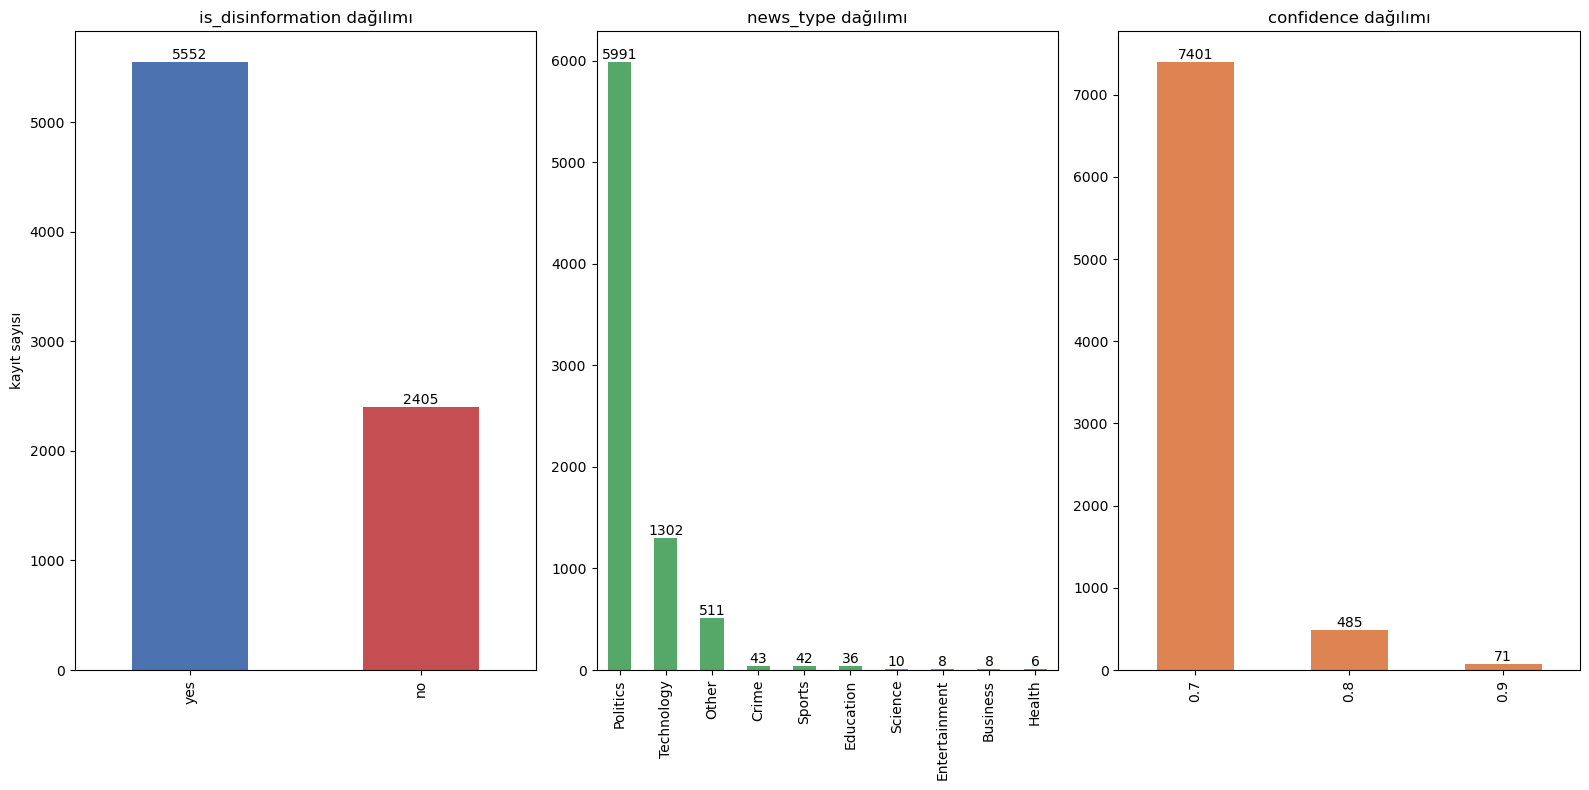


'yes' (dezenformasyon) sınıfının oranı: %69.8 -- veri seti dengesiz.


In [4]:
print("is_disinformation dağılımı:\n", df["is_disinformation"].value_counts(dropna=False))
print("\nnews_type dağılımı:\n", df["news_type"].value_counts(dropna=False))
print("\nconfidence dağılımı:\n", df["confidence"].value_counts(dropna=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

df["is_disinformation"].value_counts().plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("is_disinformation dağılımı")
axes[0].set_xlabel("")
axes[0].set_ylabel("kayıt sayısı")
axes[0].bar_label(axes[0].containers[0])

df["news_type"].value_counts().plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("news_type dağılımı")
axes[1].set_xlabel("")
axes[1].bar_label(axes[1].containers[0])

df["confidence"].value_counts().plot(kind="bar", ax=axes[2], color="#dd8452")
axes[2].set_title("confidence dağılımı")
axes[2].set_xlabel("")
axes[2].bar_label(axes[2].containers[0])

plt.tight_layout()
plt.show()

yes_orani = (df["is_disinformation"] == "yes").mean()
print(f"\n'yes' (dezenformasyon) sınıfının oranı: %{yes_orani*100:.1f} -- veri seti dengesiz.")


## Bozuk karakter (encoding) tespiti

Ham `text` sütununda, bozuk karakter kodlamasına (mojibake) işaret eden tipik karakter dizileri (â, ðŸ, Ã, vb.) aranarak kaç kayıtta bu sorunun bulunduğu tespit edilir.

In [5]:
bozuk = df[df["text"].str.contains(r"â|ðŸ|Ã|�", regex=True, na=False)]
print("Bozuk karakter şüphesi olan kayıt sayısı:", len(bozuk))

Bozuk karakter şüphesi olan kayıt sayısı: 2862


## Metin temizleme — mojibake düzeltme ve `clean_text` oluşturma


`fix_mojibake()` fonksiyonu tanımlanır: UTF-8 baytlarının yanlışlıkla cp1252 kod sayfasıyla okunmasından kaynaklanan karakter bozulmasını, metni cp1252 ile yeniden kodlayıp UTF-8 olarak çözerek düzeltir. Ayrıca markdown/URL/emoji temizliği yapan yardımcı fonksiyonlar (`clean_text_base`, `clean_text_from_base`) da burada tanımlanıp uygulanır.

In [6]:
def fix_mojibake(text):
    """UTF-8 metnin cp1252 olarak yanlış okunmasından kaynaklanan bozulmayı düzeltir.
    Not (YENİ): errors="ignore" kullanıldığı için encode/decode zaten exception fırlatmaz;
    önceki try/except bloğu hiçbir zaman tetiklenmeyen ölü kod olduğu için kaldırıldı."""
    return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")

def remove_emoji(text):
    """Emoji ve sembol/piktogram bloklarındaki unicode karakterleri kaldırır."""
    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001FAFF"  # semboller, piktogramlar, emoji
        "\U00002600-\U000027BF"  # çeşitli semboller & dingbats
        "\U0001F1E6-\U0001F1FF"  # bölgesel gösterge sembolleri (bayrak harfleri)
        "\U00002190-\U000021FF"  # oklar
        "\U0000FE0F"              # varyasyon seçici (emoji render modu)
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(' ', text)

def remove_non_latin(text):
    """ASCII dışındaki karakterleri (Kiril, Çince, vb. script'ler) kaldırır.
    SADECE clean_text (vectorization) için kullanılır -- dil tespiti için değil,
    çünkü dil tespitinin yabancı script'i görebilmesi gerekir (bkz. üstteki not)."""
    return re.sub(r'[^\x00-\x7F]+', ' ', text)

def clean_text_base(text):
    """Dil tespiti için kullanılacak ara temizlik: mojibake + markdown/URL + emoji +
    görünmez karakterler. Latin-olmayan script'ler BİLEREK korunur."""
    t = fix_mojibake(text)
    t = re.sub(r'!\[.*?\]\(.*?\)', ' ', t)          # markdown görsel
    t = re.sub(r'\[([^\]]*)\]\([^)]*\)', r'\1', t)   # markdown link -> sadece etiket metni kalsın
    t = re.sub(r'http\S+|www\.\S+', ' ', t)          # URL
    t = re.sub(r'[*_`#>~]+', ' ', t)                 # markdown biçimlendirme karakterleri
    t = remove_emoji(t)
    t = re.sub(r'[\u200b\u200e\u200f\ufeff]', ' ', t)  # görünmez unicode karakterler
    t = re.sub(r'\s+', ' ', t).strip()
    t = t.lower()
    return t

def clean_text_from_base(base_text):
    """clean_text_base çıktısı üzerine non-Latin script temizliği uygular --
    vectorization için kullanılacak son hal."""
    t = remove_non_latin(base_text)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df_clean = df.copy()
df_clean["text_for_lang"] = df_clean["text"].apply(clean_text_base)
df_clean["clean_text"] = df_clean["text_for_lang"].apply(clean_text_from_base)

print("Temizlik öncesi örnek:")
print(df_clean["text"].iloc[1][:150])
print("\nTemizlik sonrası örnek (clean_text):")
print(df_clean["clean_text"].iloc[1][:150])

kalan_bozuk = df_clean["clean_text"].str.contains(r"â|ðŸ|Ã|�", regex=True, na=False).sum()
print("\nTemizlik sonrası hâlâ bozuk görünen kayıt sayısı:", kalan_bozuk)


Temizlik öncesi örnek:
[â€‹â€‹](https://telegra.ph/file/a9b07f742b7cf18d5bad6.jpg)**Mortality from coronavirus in the USA and China**

Radio Liberty claims that in 2021 ther

Temizlik sonrası örnek (clean_text):
mortality from coronavirus in the usa and china radio liberty claims that in 2021 there we

Temizlik sonrası hâlâ bozuk görünen kayıt sayısı: 0


## Yabancı script/alfabe tespiti ve tamamen yabancı dilde kalan kayıtların çıkarılması

Metindeki alfabetik karakterlerin ne kadarının Latin-dışı bir script'e (Kiril, Çince vb.) ait olduğunu ölçen `non_latin_ratio()` fonksiyonu tanımlanır. `langdetect` kütüphanesinin kısa/gazetecilik üslubundaki İngilizce başlıklarda yanlış dil tahmini yapması nedeniyle bu özel script-tabanlı yöntem tercih edilmiştir; %16 eşik değeri, gerçek yabancı-dil içerik ile İngilizce metin içindeki tekil yabancı kelimeleri net biçimde ayırmaktadır. **Sınırlılık:** Bu eşik değeri istatistiksel bir yöntemle değil, veri setindeki birkaç örnek üzerinde gözlemsel/deneysel olarak belirlenmiştir; farklı bir veri setinde yeniden kalibre edilmesi gerekebilir.

In [7]:

# Gerçek veri üzerinde test ederken şunu bulduk: langdetect, kısa/farklı üsluplu
# İngilizce haber başlıklarında (örn. "cnn: uk delivers long-range missiles to
# ukraine." -> yanlışlıkla "no" / Norveççe) onlarca yanlış pozitif üretiyordu --
# kısa-metin eşiği bile bunu tam çözemedi (130 -> 118, hâlâ çoğu yanlış pozitif).
#
# Buna karşılık, veri setindeki GERÇEK yabancı-dil kirliliğini (örn. BBC Çince
# haberleri) doğrudan script/alfabe bazlı bir oranla çok daha güvenilir şekilde
# yakalayabiliyoruz: metnin alfabetik karakterlerinin ne kadarı Latin-olmayan
# (Kiril, Çince, vb.)? Test ettiğimizde net bir ayrım bulduk:
#   - Bilinen yanlış-pozitifler (gerçek İngilizce metinler): oran = 0.0
#   - Kanal hashtag'i olarak tek bir Kiril kelime içeren İngilizce metinler
#     (örn. "#ЦПД_інформує: Russia uses American historian...")     : oran ~0.11-0.13
#   - Gerçek yabancı-dil belgeler (BBC Çince haberleri)              : oran 0.63-0.79
# %15 eşiği bu ikisini net şekilde ayırıyor ve harici bir kütüphaneye
# (langdetect) bağımlılığı da ortadan kaldırıyor.

NON_LATIN_RATIO_THRESHOLD = 0.16

def non_latin_ratio(text):
    """Metindeki alfabetik karakterlerin ne kadarının Latin-olmayan (Kiril,
    Çince, vb.) script'e ait olduğunu 0-1 arası bir oran olarak döndürür."""
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    non_latin = [c for c in letters if ord(c) > 0x2FF]  # Latin + Latin-1 Ek bloğu dışı
    return len(non_latin) / len(letters)

# Not: "text_for_lang" kullanıyoruz (non-Latin script'ler korunmuş hali) --
# "clean_text" değil, çünkü clean_text'te bu script'ler zaten temizlenmiş olurdu.
df_clean["non_latin_ratio"] = df_clean["text_for_lang"].apply(non_latin_ratio)
df_clean["detected_lang"] = np.where(
    df_clean["non_latin_ratio"] > NON_LATIN_RATIO_THRESHOLD, "non-latin-script", "en"
)

print("Tespit dağılımı:\n", df_clean["detected_lang"].value_counts())

non_en = df_clean[df_clean["detected_lang"] != "en"]
print("\nLatin-olmayan script şüpheli kayıt sayısı:", len(non_en))
non_en[["post_id", "clean_text", "non_latin_ratio"]].sort_values("non_latin_ratio", ascending=False)


Tespit dağılımı:
 detected_lang
en                  7954
non-latin-script       3
Name: count, dtype: int64

Latin-olmayan script şüpheli kayıt sayısı: 3


,post_id,clean_text,non_latin_ratio
6170,https://www.bbc.com/zhongwen/articles/c8d80qm6...,- bbc news,0.787879
7078,https://www.bbc.com/zhongwen/articles/cx260z3k...,- bbc news,0.720000
6154,https://www.bbc.com/zhongwen/articles/cg4p93k2...,- bbc news,0.631579


Tespit edilen yabancı-script kayıtlar (`detected_lang != "en"`) veri setinden çıkarılır ve öncesi/sonrası kayıt sayısı karşılaştırılır.

In [8]:
oncesi = df_clean.shape[0]
df_clean = df_clean[df_clean["detected_lang"] == "en"].reset_index(drop=True)
print("Dil filtresi öncesi:", oncesi, "-> sonrası:", df_clean.shape[0], "  (çıkarılan:", oncesi - df_clean.shape[0], ")")

Dil filtresi öncesi: 7957 -> sonrası: 7954   (çıkarılan: 3 )


**Sızıntı kontrolü:** Dil filtresiyle çıkarılan kayıtların (`non_en`) `is_disinformation` ve `news_type` dağılımı, kalan veri setiyle karşılaştırılır. Amaç, bu filtrenin belirli bir sınıfı veya kategoriyi sistematik olarak hedef almadığını (yani modele istemsizce bir sinyal sızdırmadığını) doğrulamaktır.

In [9]:
non_en_oran = (non_en["is_disinformation"] == "yes").mean()
genel_oran = (df_clean["is_disinformation"] == "yes").mean()

print(f"Genel veri setinde 'yes' oranı: {genel_oran:.3f}")
print(f"Dil filtresiyle çıkarılan kayıtlarda 'yes' oranı: {non_en_oran:.3f}")

print("\nÇıkarılan kayıtların news_type dağılımı:")
print(non_en["news_type"].value_counts(normalize=True).round(3))

print("\nGenel veri setinin news_type dağılımı:")
print(df_clean["news_type"].value_counts(normalize=True).round(3))


Genel veri setinde 'yes' oranı: 0.698
Dil filtresiyle çıkarılan kayıtlarda 'yes' oranı: 0.000

Çıkarılan kayıtların news_type dağılımı:
news_type
Politics    1.0
Name: proportion, dtype: float64

Genel veri setinin news_type dağılımı:
news_type
Politics         0.753
Technology       0.164
Other            0.064
Crime            0.005
Sports           0.005
Education        0.005
Science          0.001
Entertainment    0.001
Business         0.001
Health           0.001
Name: proportion, dtype: float64


## Konu dışı (alakasız) haberlerin tespiti ve temizlenmesi

Rusya-Ukrayna savaşıyla alakasız olabilecek (İsrail/Gazze, İran/Suriye, Tayvan, Afganistan, Covid, Kosova gibi) konulardaki kayıtlar, anahtar kelime eşleştirmesiyle tespit edilir. Ukrayna/Rusya ile ilişkili terim içerenler (gerçekte konuyla ilgili olabileceğinden) korunur, geri kalanlar veri setinden çıkarılır.

In [10]:
# Rusya-Ukrayna savasiyla alakasiz olabilecek haberler icin aday kelime gruplari
keywords = [
    "israel", "israeli", "lebanon", "lebanese",
    "hezbollah", "gaza", "hamas", "palestine", "palestinian",
    "syria", "syrian", "iran", "iranian",
    "taiwan", "taiwanese", "afghanistan", "afghan", "libya",
    "covid", "coronavirus", "kosovo"
]
pattern = "|".join(keywords)
adaylar = df_clean[df_clean["clean_text"].str.contains(pattern, case=False, na=False, regex=True)].copy()
print("Aday kayit sayisi:", len(adaylar))

# Icinde Ukrayna-Rusya ile ilgili anahtar kelime gecenleri haric tut (konuyla ilgili olabilirler)
ukraine_russia_keywords = [
    "ukraine", "ukrainian", "ukrainians", "russia", "russian", "russians",
    "putin", "zelensky", "zelenskiy", "kyiv", "kiev", "kremlin", "moscow",
    "donbas", "crimea", "nato"
]
pattern_ur = "|".join(ukraine_russia_keywords)

# --- Grup 1: Israil/Lubnan/Gazze ---
israel_group = ["israel", "israeli", "lebanon", "lebanese", "hezbollah", "gaza", "hamas", "palestine", "palestinian"]
pattern_israel = "|".join(israel_group)
israel_aday = adaylar[adaylar["clean_text"].str.contains(pattern_israel, case=False, na=False, regex=True)].copy()
israel_irrelevant_candidates = israel_aday[
    ~israel_aday["clean_text"].str.contains(pattern_ur, case=False, na=False, regex=True)
].copy()
print("Israil/Lubnan/Gazze grubu aday:", len(israel_aday), "-> alakasiz:", len(israel_irrelevant_candidates))

# --- Grup 2: Iran/Suriye/Taiwan/Afganistan/Libya/Covid/Kosova ---
# Bu grup elle incelendi (iran_syria_inceleme.xlsx); sadece asagidaki 2 kayit
# gercekten Rusya-Ukrayna savasiyla ilgili bulundu (Iran drone/Suriye-Wagner baglami),
# geri kalan kayitlar alakasiz kabul edildi.
other_keywords = ["syria", "syrian", "iran", "iranian", "taiwan", "taiwanese",
                   "afghanistan", "afghan", "libya", "covid", "coronavirus", "kosovo"]
pattern_other = "|".join(other_keywords)
# Not (YENİ) isimlendirme netligi: "other_candidates" burada zaten Ukrayna-Rusya
# kelimesi GECMEYEN (yani zaten "alakasiz aday" olan) kayitlari tutuyor -- "candidates"
# ismi henuz karar verilmemis gibi izlenim veriyor olabilir, bunu belirtmek icin not dustum.
other_aday = adaylar[adaylar["clean_text"].str.contains(pattern_other, case=False, na=False, regex=True)].copy()
other_candidates = other_aday[
    ~other_aday["clean_text"].str.contains(pattern_ur, case=False, na=False, regex=True)
].copy()  # zaten "alakasiz" olan alt kume -- manuel_alakali_id ile birazi geri eklenecek

manuel_alakali_id = ["telegram_rybar_32598", "telegram_rybar_40577"]
other_irrelevant_candidates = other_candidates[~other_candidates["post_id"].isin(manuel_alakali_id)].copy()
print("Iran/Suriye/... grubu aday:", len(other_candidates), "-> alakasiz:", len(other_irrelevant_candidates))

# --- Alakasiz kayitlari veri setinden cikar ---
irrelevant_all = pd.concat([israel_irrelevant_candidates, other_irrelevant_candidates])
oncesi = df_clean.shape[0]
df_clean = df_clean.drop(index=irrelevant_all.index.unique())
print("\nÖnceki boyut:", oncesi)
print("Yeni boyut:", df_clean.shape[0])
print("Silinen kayit:", oncesi - df_clean.shape[0])

Aday kayit sayisi: 515
Israil/Lubnan/Gazze grubu aday: 189 -> alakasiz: 133
Iran/Suriye/... grubu aday: 270 -> alakasiz: 268

Önceki boyut: 7954
Yeni boyut: 7598
Silinen kayit: 356


**Sızıntı kontrolü:** Konu-dışı filtresiyle çıkarılan kayıtların (`irrelevant_all`) `is_disinformation` oranı ve `news_type` dağılımı, genel veri setiyle karşılaştırılır. Çıkarılan kayıtlardaki "yes" oranının genel orandan çok sapmaması, bu filtrenin dezenformasyon etiketiyle karıştırılan bir örüntü yakalamadığını (yani konu-alaka filtresinin dolaylı bir sınıf filtresine dönüşmediğini) gösterir.

In [11]:
irrelevant_oran = (irrelevant_all["is_disinformation"] == "yes").mean()
genel_oran_2 = (df["is_disinformation"] == "yes").mean()

print(f"Genel veri setinde 'yes' oranı: {genel_oran_2:.3f}")
print(f"Konu-dışı filtresiyle çıkarılan kayıtlarda 'yes' oranı: {irrelevant_oran:.3f}")

print("\nÇıkarılan kayıtların news_type dağılımı:")
print(irrelevant_all["news_type"].value_counts(normalize=True).round(3))


Genel veri setinde 'yes' oranı: 0.698
Konu-dışı filtresiyle çıkarılan kayıtlarda 'yes' oranı: 0.135

Çıkarılan kayıtların news_type dağılımı:
news_type
Technology    0.434
Other         0.379
Politics      0.175
Health        0.005
Crime         0.005
Science       0.002
Name: proportion, dtype: float64


## Çok kısa kalan metinlerin temizlenmesi

`clean_text` uzunluğu 25 karakterin altında kalan (genellikle kaynakta zaten kırpılmış gelen) kayıtlar tespit edilip veri setinden çıkarılır; bu kayıtlar anlamlı bir sınıflandırma sinyali taşımayacak kadar kısadır.

In [12]:
kisa_metin_mask = df_clean["clean_text"].str.len() < 25
silinenler = df_clean[kisa_metin_mask].copy()

print("Silinecek cok kisa/bos kayit sayisi:", kisa_metin_mask.sum())
df_clean = df_clean[~kisa_metin_mask].reset_index(drop=True)
print("Kisa metinler cikarildiktan sonra veri seti boyutu:", df_clean.shape)

print("\nSilinen kayitlar:")
silinenler[["post_id", "clean_text", "is_disinformation", "news_type"]]

Silinecek cok kisa/bos kayit sayisi: 12
Kisa metinler cikarildiktan sonra veri seti boyutu: (7586, 9)

Silinen kayitlar:


,post_id,clean_text,is_disinformation,news_type
545,telegram_KyivIndependent_official_13399,putin claims pat,yes,Politics
1210,telegram_KyivIndependent_official_33473,moscow claims,yes,Politics
1577,telegram_KyivIndependent_official_41210,' false story ' d,yes,Politics
1716,telegram_KyivIndependent_official_44458,moscow claims,yes,Technology
1753,telegram_KyivIndependent_official_45301,eu [ mulls ](,yes,Politics
1869,telegram_KyivIndependent_official_47432,trump reportedly tells,yes,Politics
2032,telegram_KyivIndependent_official_50032,russia claims receipt of,yes,Politics
6058,https://www.bbc.com/swahili/extra/5wlhmbbbvr/a...,swahili away from home,no,Politics
6094,https://www.bbc.com/afrique/extra/uelbvocdqx/a...,french trapped version 2,no,Politics
6693,https://www.dw.com/bs/%C5%A1amar-rusima/a-7828...,"""a slap to the russians",no,Politics


In [13]:
kisa_oran = (silinenler["is_disinformation"] == "yes").mean()
genel_oran_3 = (df_clean["is_disinformation"] == "yes").mean()  # not: df_clean burada filtre SONRASI hali

print(f"Genel veri setinde 'yes' oranı: {genel_oran_3:.3f}")
print(f"Çok kısa metin filtresiyle çıkarılan kayıtlarda 'yes' oranı: {kisa_oran:.3f}")

print("\nÇıkarılan kayıtların news_type dağılımı:")
print(silinenler["news_type"].value_counts(normalize=True).round(3))

print("\nGenel veri setinin news_type dağılımı:")
print(df_clean["news_type"].value_counts(normalize=True).round(3))

Genel veri setinde 'yes' oranı: 0.724
Çok kısa metin filtresiyle çıkarılan kayıtlarda 'yes' oranı: 0.583

Çıkarılan kayıtların news_type dağılımı:
news_type
Politics      0.833
Technology    0.083
Other         0.083
Name: proportion, dtype: float64

Genel veri setinin news_type dağılımı:
news_type
Politics         0.779
Technology       0.151
Other            0.050
Sports           0.006
Crime            0.005
Education        0.005
Science          0.001
Entertainment    0.001
Business         0.001
Health           0.001
Name: proportion, dtype: float64


## Metin/hedef ayrımı ve eğitim-test bölmesi

Temizlenmiş metin (`clean_text`) ve hedef değişken (`is_disinformation`), sınıf oranı korunacak şekilde (`stratify`) %80 eğitim / %20 test olarak ikiye bölünür.

In [ ]:
X_text = df_clean["clean_text"]
X_news_type = df_clean[["news_type"]]   # 2D olmali, OneHotEncoder icin
y = df_clean["is_disinformation"]

X_train_text, X_test_text, X_train_news, X_test_news, y_train, y_test = train_test_split(
    X_text, X_news_type, y, test_size=0.20, random_state=42, stratify=y
)

print("Eğitim veri sayısı:", len(X_train_text))
print("Test veri sayısı:", len(X_test_text))
print("\nEğitim sınıf dağılımı:\n", y_train.value_counts())
print("\nTest sınıf dağılımı:\n", y_test.value_counts())

## 11. TF-IDF vektörleştirme

`TfidfVectorizer` ile metinler sayısal vektörlere dönüştürülür. `stop_words="english"` yaygın İngilizce dolgu kelimelerini, `min_df=3`/`max_df=0.9` nadir/aşırı yaygın kelimeleri filtreler, `ngram_range=(1,2)` hem tekil kelimeleri hem ikili kelime gruplarını (bigram) özellik olarak kullanır.

In [15]:
tfidf = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.9, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF eğitim veri boyutu:", X_train_tfidf.shape)
print("TF-IDF test veri boyutu:", X_test_tfidf.shape)

TF-IDF eğitim veri boyutu: (6068, 11143)
TF-IDF test veri boyutu: (1518, 11143)


## TF-IDF kelime dağarcığı kontrolü

Oluşan TF-IDF kelime dağarcığının toplam boyutu ve ilk 20 özelliği (alfabetik sırayla) görüntülenerek vektörleştirmenin beklenen şekilde çalıştığı doğrulanır.

In [16]:
feature_names = tfidf.get_feature_names_out()

print("Toplam özellik (kelime/kelime öbeği) sayısı:", len(feature_names))
print("\nİlk 20 özellik:")
print(feature_names[:20])

Toplam özellik (kelime/kelime öbeği) sayısı: 11143

İlk 20 özellik:
['00' '000' '000 dollars' '000 people' '000 soldiers' '01' '02' '02 03'
 '03' '03 2023' '04' '05' '05 occupiers' '06' '06 occupiers' '07' '08'
 '08 2022' '09' '10']


## 12. (Opsiyonel) CountVectorizer karşılaştırması

Karşılaştırma amacıyla, TF-IDF ile aynı parametrelere sahip bir `CountVectorizer` (ham kelime sayımı) oluşturulur.

In [17]:
count_vectorizer = CountVectorizer(stop_words="english", min_df=3, max_df=0.9, ngram_range=(1, 2))

X_train_count = count_vectorizer.fit_transform(X_train_text)
X_test_count = count_vectorizer.transform(X_test_text)

print("CountVectorizer eğitim veri boyutu:", X_train_count.shape)
print("CountVectorizer test veri boyutu:", X_test_count.shape)

CountVectorizer eğitim veri boyutu: (6068, 11143)
CountVectorizer test veri boyutu: (1518, 11143)


`CountVectorizer`'ın ürettiği kelime dağarcığının boyutu ve ilk 20 özelliği görüntülenir.

In [18]:
count_features = count_vectorizer.get_feature_names_out()

print("CountVectorizer toplam özellik sayısı:", len(count_features))
print("\nİlk 20 özellik:")
print(count_features[:20])

CountVectorizer toplam özellik sayısı: 11143

İlk 20 özellik:
['00' '000' '000 dollars' '000 people' '000 soldiers' '01' '02' '02 03'
 '03' '03 2023' '04' '05' '05 occupiers' '06' '06 occupiers' '07' '08'
 '08 2022' '09' '10']


TF-IDF ve `CountVectorizer`'ın aynı kelime dağarcığını üretip üretmediği (`np.array_equal`) karşılaştırılarak iki vektörleştiricinin tutarlılığı doğrulanır.

In [19]:
# TF-IDF ve CountVectorizer'ın aynı kelime dağarcığını ürettiğini doğrulamak için karşılaştır
ayni_mi = np.array_equal(count_features, feature_names)
print("İki vektörleştiricinin kelime dağarcığı birebir aynı mı?", ayni_mi)

print("\nSon 20 CountVectorizer özelliği:")
print(count_features[-20:])
print("\nSon 20 TF-IDF özelliği:")
print(feature_names[-20:])

İki vektörleştiricinin kelime dağarcığı birebir aynı mı? True

Son 20 CountVectorizer özelliği:
['zelenskyy plan' 'zelenskyy regime' 'zelenskyy said' 'zelenskyy signed'
 'zelenskyy team' 'zelenskyy trying' 'zelenskyy usurped'
 'zelenskyy victory' 'zelenskyy visit' 'zelenskyy wants' 'zelenskyy warns'
 'zelenskyy washington' 'zelenskyy west' 'zelenskyy western'
 'zelenskyy zelenskyy' 'zone' 'zone special' 'zone ukraine' 'zone western'
 'zones']

Son 20 TF-IDF özelliği:
['zelenskyy plan' 'zelenskyy regime' 'zelenskyy said' 'zelenskyy signed'
 'zelenskyy team' 'zelenskyy trying' 'zelenskyy usurped'
 'zelenskyy victory' 'zelenskyy visit' 'zelenskyy wants' 'zelenskyy warns'
 'zelenskyy washington' 'zelenskyy west' 'zelenskyy western'
 'zelenskyy zelenskyy' 'zone' 'zone special' 'zone ukraine' 'zone western'
 'zones']


## Sayısal-sadece token'ların temizlenmesi


Yalnızca rakam ve boşluktan oluşan (örn. tarih kalıntısı "03 2023" gibi) anlamsız token'lar tespit edilip kelime dağarcığından çıkarılır. "000 soldiers" gibi sayı+kelime ikilileri bilinçli olarak korunur, çünkü dezenformasyon tespiti için potansiyel bir sinyal taşıyabilir.

In [20]:
import re as _re

def sayisal_sadece_mi(token):
    return bool(_re.fullmatch(r"[\d\s]+", token))

sayisal_mask = np.array([sayisal_sadece_mi(f) for f in feature_names])
print("Sayisal-sadece token sayisi (TF-IDF/Count vocabulary ayni oldugu icin ikisi icin de gecerli):", sayisal_mask.sum())
print("Ornekler:", feature_names[sayisal_mask][:15])

keep_idx = np.where(~sayisal_mask)[0]

# TF-IDF matrislerini ve feature_names'i guncelle
X_train_tfidf = X_train_tfidf[:, keep_idx]
X_test_tfidf = X_test_tfidf[:, keep_idx]
feature_names = feature_names[keep_idx]

# CountVectorizer matrislerini de tutarlilik icin ayni sekilde guncelle
X_train_count = X_train_count[:, keep_idx]
X_test_count = X_test_count[:, keep_idx]
count_features = count_features[keep_idx]

print("\nTemizlik sonrasi TF-IDF egitim boyutu:", X_train_tfidf.shape)
print("Temizlik sonrasi TF-IDF test boyutu:", X_test_tfidf.shape)
print("\nIlk 20 ozellik (alfabetik, sayisal token'lar cikarilmis):")
print(feature_names[:20])


Sayisal-sadece token sayisi (TF-IDF/Count vocabulary ayni oldugu icin ikisi icin de gecerli): 106
Ornekler: ['00' '000' '01' '02' '02 03' '03' '03 2023' '04' '05' '06' '07' '08'
 '08 2022' '09' '10']

Temizlik sonrasi TF-IDF egitim boyutu: (6068, 11037)
Temizlik sonrasi TF-IDF test boyutu: (1518, 11037)

Ilk 20 ozellik (alfabetik, sayisal token'lar cikarilmis):
['000 dollars' '000 people' '000 soldiers' '05 occupiers' '06 occupiers'
 '10 million' '10 years' '100 years' '12 years' '13th' '14 russian'
 '15 million' '15 years' '16 fighter' '16 fighters' '16 years' '16s'
 '17 million' '17th' '19 pandemic']


## `news_type` sütununun X'e eklenmesi

Şimdiye kadar model yalnızca metni (`clean_text` -> TF-IDF) girdi olarak kullanıyordu. Hocamızın isteği doğrultusunda, haber kategorisini (`news_type`) de bir özellik olarak modele eklemek için bu sütun `OneHotEncoder` ile sayısallaştırılıp TF-IDF matrisine yatay olarak (`hstack`) birleştirilir. **Sızıntı kontrolü:** encoder yalnızca eğitim verisiyle (`X_train_news`) `fit` edilir; test verisine sadece `transform` uygulanır — tıpkı yukarıdaki TF-IDF adımında olduğu gibi. `handle_unknown="ignore"` parametresi, test setinde eğitim setinde görülmemiş bir kategori çıkarsa (örn. çok nadir görülen `Health`/`Business` gibi kategoriler) hatanın önüne geçer.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

# news_type'i one-hot encode et (sadece train'e fit, test'e sadece transform)
ohe = OneHotEncoder(handle_unknown="ignore")
X_train_news_ohe = ohe.fit_transform(X_train_news)
X_test_news_ohe = ohe.transform(X_test_news)

print("news_type kategorileri:", ohe.categories_[0])
print("One-hot boyutu (train):", X_train_news_ohe.shape)

# TF-IDF ile news_type'i yan yana birlestir
X_train_tfidf = hstack([X_train_tfidf, X_train_news_ohe]).tocsr()
X_test_tfidf = hstack([X_test_tfidf, X_test_news_ohe]).tocsr()

print("\nBirlestirilmis X_train_tfidf boyutu:", X_train_tfidf.shape)
print("Birlestirilmis X_test_tfidf boyutu:", X_test_tfidf.shape)

# feature_names'i de guncelle: asagidaki katsayi/onem analizi hucreleri
# (Linear SVM, Random Forest, XGBoost, Multinomial NB) dogru isimlerle calissin diye
feature_names = np.concatenate([feature_names, ohe.get_feature_names_out()])
print("\nEklenen news_type ozellikleri:", list(ohe.get_feature_names_out()))

## Sınıflandırma modeli 

`DummyClassifier(strategy="most_frequent")` ile bir referans (baseline) model kurulur: bu model her zaman çoğunluk sınıfını ("yes") tahmin eder. Sonraki tüm modellerin performansı bu baseline ile karşılaştırılacaktır.

In [21]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_tfidf, y_train)
baseline_pred = baseline.predict(X_test_tfidf)
print("Baseline (çoğunluk sınıfı) accuracy:", accuracy_score(y_test, baseline_pred))

print("\nBaseline classification report:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline (çoğunluk sınıfı) accuracy: 0.7246376811594203

Baseline classification report:
              precision    recall  f1-score   support

          no       0.00      0.00      0.00       418
         yes       0.72      1.00      0.84      1100

    accuracy                           0.72      1518
   macro avg       0.36      0.50      0.42      1518
weighted avg       0.53      0.72      0.61      1518



### 1. Logistic Regression

Logistic Regression modeli varsayılan ayarlarla eğitilir ve test setinde accuracy, precision, recall, F1 skoru ile confusion matrix hesaplanır.

Accuracy : 0.922266139657444
Precision: 0.9112227805695142
Recall   : 0.9890909090909091
F1 Score : 0.948561464690497

Classification Report:

              precision    recall  f1-score   support

          no       0.96      0.75      0.84       418
         yes       0.91      0.99      0.95      1100

    accuracy                           0.92      1518
   macro avg       0.94      0.87      0.89      1518
weighted avg       0.93      0.92      0.92      1518



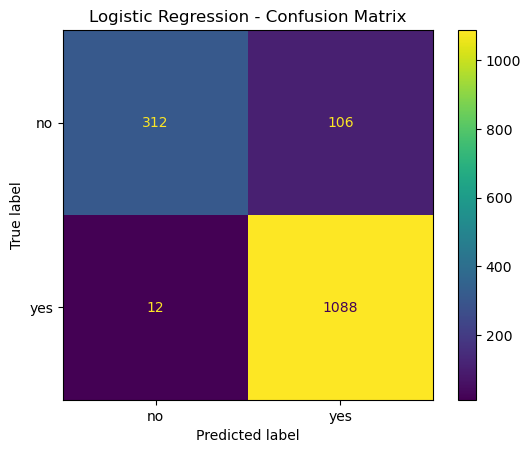

In [22]:
# Model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
# Eğit
lr_model.fit(X_train_tfidf, y_train)
# Tahmin
y_pred_lr = lr_model.predict(X_test_tfidf)
# Metrikler
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    labels=["no", "yes"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()



### 2.Linear SVM

Linear SVM (Support Vector Classifier) modeli varsayılan ayarlarla eğitilir ve aynı metriklerle değerlendirilir.

Accuracy : 0.9604743083003953
Precision: 0.9676258992805755
Recall   : 0.9781818181818182
F1 Score : 0.972875226039783

Classification Report:

              precision    recall  f1-score   support

          no       0.94      0.91      0.93       418
         yes       0.97      0.98      0.97      1100

    accuracy                           0.96      1518
   macro avg       0.95      0.95      0.95      1518
weighted avg       0.96      0.96      0.96      1518



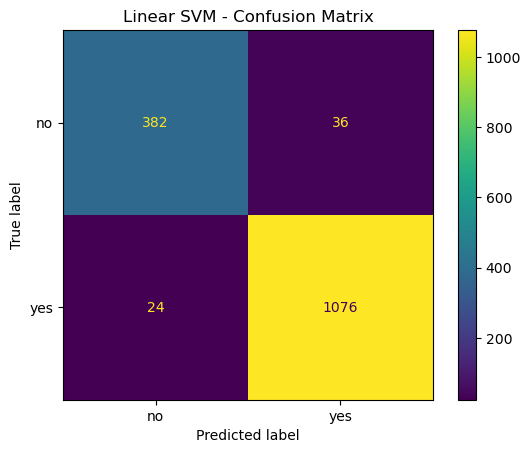

In [23]:
# Model
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)
# Eğit
svm_model.fit(X_train_tfidf, y_train)
# Tahmin
y_pred_svm = svm_model.predict(X_test_tfidf)
# Metrikler
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_svm, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_svm, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    labels=["no", "yes"]
)
plt.title("Linear SVM - Confusion Matrix")
plt.show()



### 3. Complement Naive Bayes

Dengesiz sınıflar için özel olarak tasarlanmış Complement Naive Bayes modeli eğitilir ve değerlendirilir.

Accuracy : 0.9117259552042161
Precision: 0.917098445595855
Recall   : 0.9654545454545455
F1 Score : 0.9406554472984943

Classification Report:

              precision    recall  f1-score   support

          no       0.89      0.77      0.83       418
         yes       0.92      0.97      0.94      1100

    accuracy                           0.91      1518
   macro avg       0.91      0.87      0.88      1518
weighted avg       0.91      0.91      0.91      1518



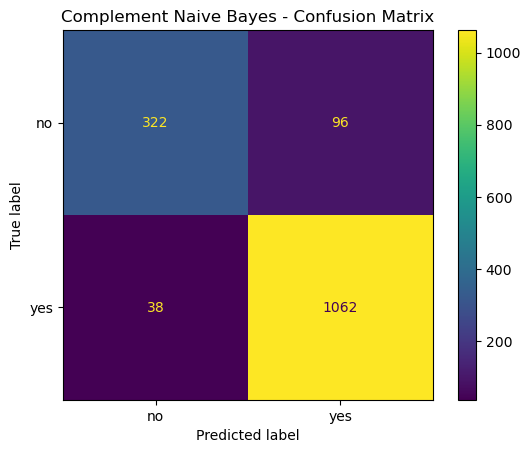

In [24]:
# Model
cnb_model = ComplementNB(
    alpha=1.0
)
# Eğit
cnb_model.fit(X_train_tfidf, y_train)
# Tahmin
y_pred_cnb = cnb_model.predict(X_test_tfidf)
# Metrikler
print("Accuracy :", accuracy_score(y_test, y_pred_cnb))
print("Precision:", precision_score(y_test, y_pred_cnb, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_cnb, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_cnb, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cnb))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnb,
    labels=["no", "yes"]
)
plt.title("Complement Naive Bayes - Confusion Matrix")
plt.show()


### 4. Multinomial Naive Bayes

Klasik Multinomial Naive Bayes modeli eğitilir ve değerlendirilir; bu model dengesiz veri setlerinde azınlık sınıfı hafife alma eğilimindedir, bu yüzden Complement NB ile karşılaştırma yapılabilir.

Accuracy : 0.8544137022397892
Precision: 0.836266258607498
Recall   : 0.9936363636363637
F1 Score : 0.9081844619858745

Classification Report:

              precision    recall  f1-score   support

          no       0.97      0.49      0.65       418
         yes       0.84      0.99      0.91      1100

    accuracy                           0.85      1518
   macro avg       0.90      0.74      0.78      1518
weighted avg       0.87      0.85      0.84      1518



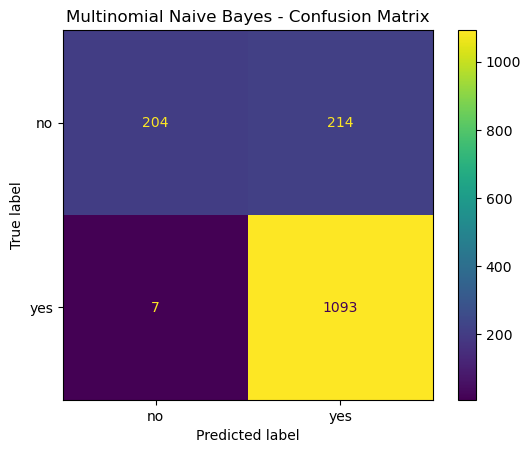

In [25]:
# Model
mnb_model = MultinomialNB(
    alpha=1.0
)
# Eğit
mnb_model.fit(X_train_tfidf, y_train)
# Tahmin
y_pred_mnb = mnb_model.predict(X_test_tfidf)
# Metrikler
print("Accuracy :", accuracy_score(y_test, y_pred_mnb))
print("Precision:", precision_score(y_test, y_pred_mnb, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_mnb, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_mnb, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mnb))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mnb,
    labels=["no", "yes"]
)
plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.show()



### 5. Random Forest

Random Forest (300 ağaçlı ensemble) modeli varsayılan ayarlarla eğitilir ve değerlendirilir.

Accuracy : 0.958498023715415
Precision: 0.9752520623281393
Recall   : 0.9672727272727273
F1 Score : 0.9712460063897763

Classification Report:

              precision    recall  f1-score   support

          no       0.92      0.94      0.93       418
         yes       0.98      0.97      0.97      1100

    accuracy                           0.96      1518
   macro avg       0.95      0.95      0.95      1518
weighted avg       0.96      0.96      0.96      1518



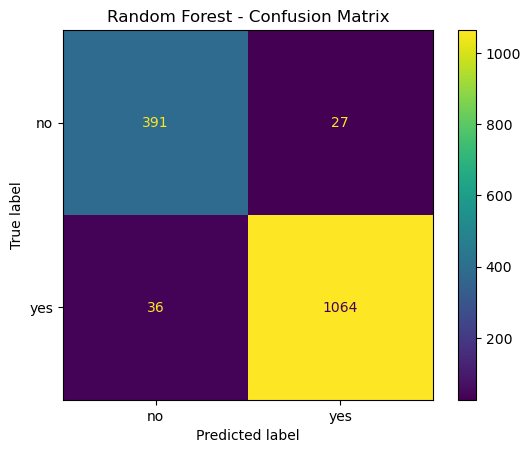

In [26]:
# Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Eğit
rf_model.fit(X_train_tfidf, y_train)

# Tahmin
y_pred_rf = rf_model.predict(X_test_tfidf)

# Metrikler
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="yes"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=["no", "yes"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

### 6. XGBoost


XGBoost (gradyan artırma/boosting) modeli varsayılan ayarlarla eğitilir ve değerlendirilir. Hedef değişken bu model için 0/1 olarak sayısallaştırılır.

Accuracy : 0.9677206851119895
Precision: 0.9925023430178069
Recall   : 0.9627272727272728
F1 Score : 0.9773880941393632

Classification Report:

              precision    recall  f1-score   support

          no       0.91      0.98      0.94       418
         yes       0.99      0.96      0.98      1100

    accuracy                           0.97      1518
   macro avg       0.95      0.97      0.96      1518
weighted avg       0.97      0.97      0.97      1518



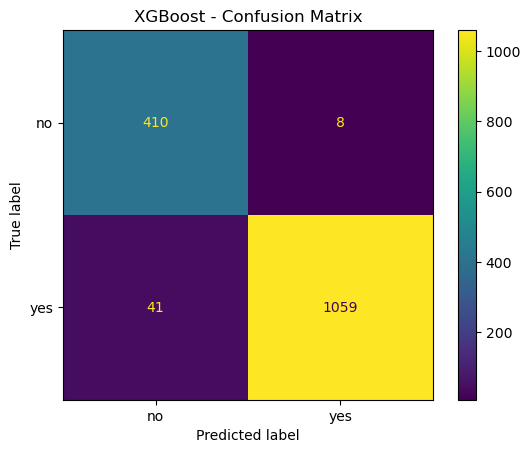

In [27]:
from xgboost import XGBClassifier  # ayri hücrede tutuluyor: xgboost kurulu degilse sadece bu ve alt hucreler etkilensin

# Hedef değişkeni 0/1'e dönüştür
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

# Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Eğit
xgb_model.fit(X_train_tfidf, y_train_xgb)

# Tahmin
y_pred_xgb = xgb_model.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test_xgb, y_pred_xgb))
print("Precision:", precision_score(y_test_xgb, y_pred_xgb))
print("Recall   :", recall_score(y_test_xgb, y_pred_xgb))
print("F1 Score :", f1_score(y_test_xgb, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(
    y_test_xgb,
    y_pred_xgb,
    target_names=["no", "yes"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    y_pred_xgb,
    display_labels=["no", "yes"]
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

Altı modelin (Logistic Regression, Linear SVM, Multinomial NB, Complement NB, Random Forest, XGBoost) accuracy ve "no" sınıfı recall değerleri tek bir grafikte karşılaştırılır. Bu, hangi modellerin dengesiz veri setinde daha güvenilir olduğunu görsel olarak özetler.

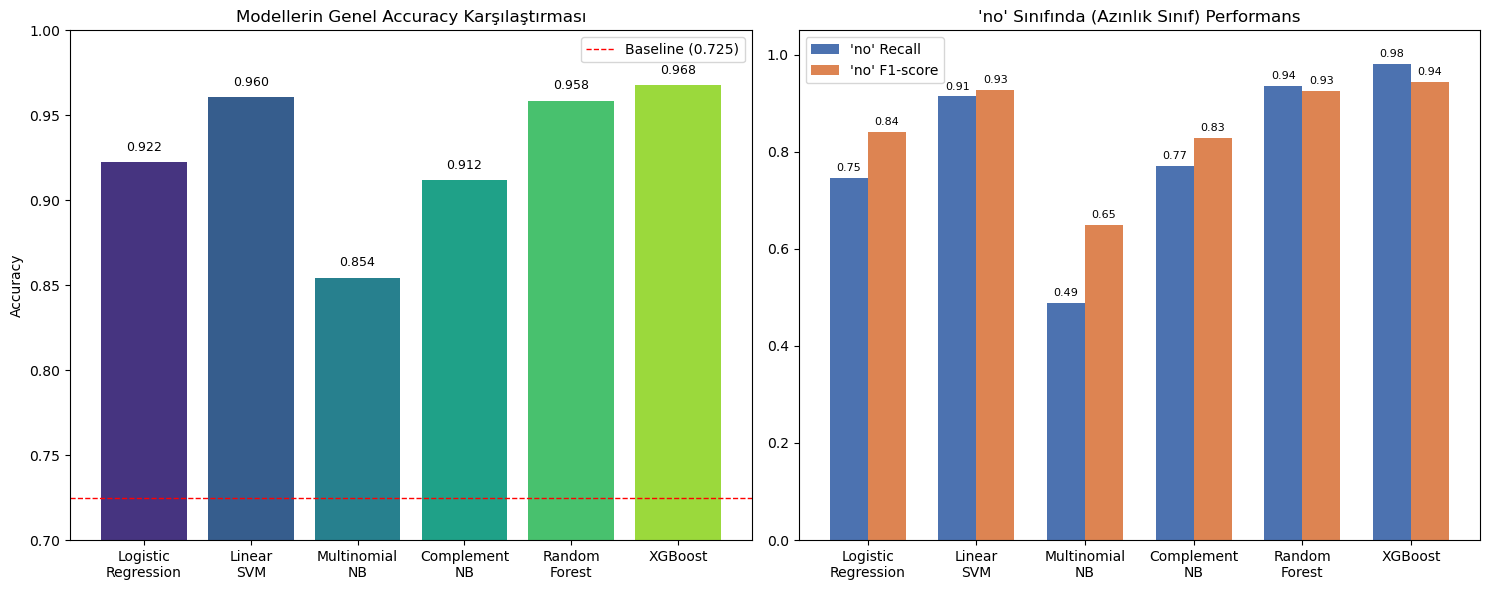

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Her modelin classification_report'undan "no" sinifi metriklerini ve genel accuracy'yi topla
model_sonuclari = {
    "Logistic\nRegression": (y_test, y_pred_lr),
    "Linear\nSVM":          (y_test, y_pred_svm),
    "Multinomial\nNB":      (y_test, y_pred_mnb),
    "Complement\nNB":       (y_test, y_pred_cnb),
    "Random\nForest":       (y_test, y_pred_rf),
    "XGBoost":              (y_test_xgb, y_pred_xgb),  # 0/1 etiketli
}

modeller, accuracy, no_recall, no_f1 = [], [], [], []
for isim, (yt, yp) in model_sonuclari.items():
    # XGBoost 0/1 etiketli oldugu icin target_names ile "no"/"yes" karsiligini alıyoruz
    target_names = ["no", "yes"] if set(np.unique(yt)) == {0, 1} else None
    rapor = classification_report(yt, yp, target_names=target_names, output_dict=True)
    modeller.append(isim)
    accuracy.append(accuracy_score(yt, yp))
    no_recall.append(rapor["no"]["recall"])
    no_f1.append(rapor["no"]["f1-score"])

baseline_acc = (y_test == "yes").mean()  # coğunluk sınıfı orani

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Grafik 1: Genel Accuracy ---
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(modeller)))
bars1 = ax1.bar(modeller, accuracy, color=colors)
ax1.set_ylim(0.7, 1.0)
ax1.set_ylabel("Accuracy")
ax1.set_title("Modellerin Genel Accuracy Karşılaştırması")
ax1.axhline(baseline_acc, color="red", linestyle="--", linewidth=1,
            label=f"Baseline ({baseline_acc:.3f})")
ax1.legend()
for bar, val in zip(bars1, accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
              ha="center", va="bottom", fontsize=9)

# --- Grafik 2: "no" (gerçek haber) sınıfı recall & f1 ---
ax2 = axes[1]
x = np.arange(len(modeller))
width = 0.35
bars2a = ax2.bar(x - width/2, no_recall, width, label="'no' Recall", color="#4C72B0")
bars2b = ax2.bar(x + width/2, no_f1, width, label="'no' F1-score", color="#DD8452")
ax2.set_xticks(x)
ax2.set_xticklabels(modeller)
ax2.set_ylim(0, 1.05)
ax2.set_title("'no' Sınıfında (Azınlık Sınıf) Performans")
ax2.legend()
for bars in (bars2a, bars2b):
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                  ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Hiperparametre Optimizasyonu

**Kapsam notu:** Hiperparametre araması altı modelin tamamı için yapılmıştır: Linear SVM, Logistic Regression (`C`, `class_weight`), Multinomial NB ve Complement NB (`alpha`), Random Forest ve XGBoost (`n_estimators`, `max_depth`, sınıf dengesizliği ağırlıkları). Böylece aşağıdaki karşılaştırmalar, ayarlanmış ve ayarlanmamış modelleri karıştırmadan tüm modellerin en iyi haliyle yapılmaktadır.

### 1. Linear SVM GridSearchCV

Linear SVM için `GridSearchCV` ile hiperparametre araması yapılır: `C` (düzenlileştirme gücü) ve `class_weight` (sınıf dengesizliği düzeltmesi) parametreleri, 5 katlı çapraz doğrulama ile taranır.

In [29]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}
grid_svm = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_svm.fit(X_train_tfidf, y_train)
print("Best params:", grid_svm.best_params_)
print("Best CV Macro F1:", grid_svm.best_score_)

Best params: {'C': 2, 'class_weight': 'balanced'}
Best CV Macro F1: 0.9473710542461953


GridSearchCV'nin bulduğu en iyi SVM modeli (`best_estimator_`) test setinde değerlendirilir ve sonuçlar (accuracy, precision, recall, F1, confusion matrix) raporlanır.

Accuracy : 0.9637681159420289
Precision: 0.9789184234647113
Recall   : 0.9709090909090909
F1 Score : 0.9748973071656778

Classification Report:

              precision    recall  f1-score   support

          no       0.93      0.94      0.93       418
         yes       0.98      0.97      0.97      1100

    accuracy                           0.96      1518
   macro avg       0.95      0.96      0.95      1518
weighted avg       0.96      0.96      0.96      1518



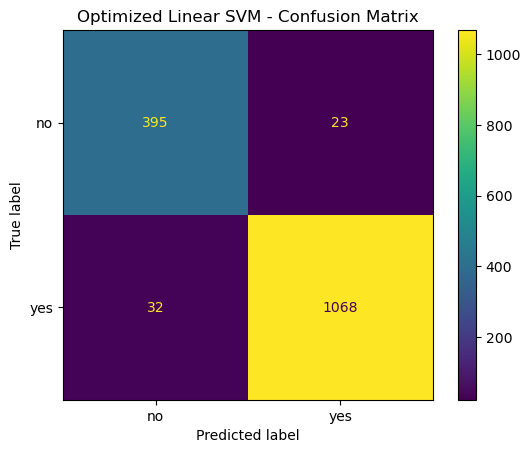

In [30]:
best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_best_svm))
print("Precision:", precision_score(
    y_test, y_pred_best_svm, pos_label="yes"
))
print("Recall   :", recall_score(
    y_test, y_pred_best_svm, pos_label="yes"
))
print("F1 Score :", f1_score(
    y_test, y_pred_best_svm, pos_label="yes"
))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_svm))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_svm,
    labels=["no", "yes"]
)

plt.title("Optimized Linear SVM - Confusion Matrix")
plt.show()

### 2. XGBoost GridSearchCV

XGBoost için `GridSearchCV` ile hiperparametre araması yapılır: `n_estimators`, `max_depth`, `learning_rate` ve sınıf dengesizliğini düzeltmeyi hedefleyen `scale_pos_weight` parametreleri taranır.

**Genişletilmiş arama:** İlk taramada en iyi `n_estimators` (300) ve `learning_rate` (0.3) üst sınırda, `max_depth` (3) ise alt sınırda çıkmıştı — üçü birden sınırda çıkması, bu aralığın XGBoost için yetersiz kaldığına işaret eder. Aralıklar buna göre genişletildi. Not: aday sayısı arttığı için bu hücre öncekinden belirgin şekilde daha uzun sürecektir.

In [31]:
# XGBoost için hiperparametreler
param_grid_xgb = {
    "n_estimators": [200, 300, 400, 500],       # 300 sinirda cikmisti, yukari genisletildi
    "max_depth": [2, 3, 6, 9],                  # 3 sinirda cikmisti, asagi genisletildi
    "learning_rate": [0.05, 0.1, 0.2, 0.3, 0.4, 0.5],  # 0.3 sinirda cikmisti, yukari genisletildi
    "scale_pos_weight": [1, len(y_train_xgb[y_train_xgb==0]) / len(y_train_xgb[y_train_xgb==1])]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_tfidf, y_train_xgb)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Macro F1:", grid_xgb.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Parameters: {'learning_rate': 0.4, 'max_depth': 2, 'n_estimators': 400, 'scale_pos_weight': 1}
Best CV Macro F1: 0.9589870242150154


En iyi XGBoost modeli test setinde değerlendirilir ve sonuçlar raporlanır.

Accuracy : 0.9696969696969697
Precision: 0.9916044776119403
Recall   : 0.9663636363636363
F1 Score : 0.9788213627992634

Classification Report:

              precision    recall  f1-score   support

          no       0.92      0.98      0.95       418
         yes       0.99      0.97      0.98      1100

    accuracy                           0.97      1518
   macro avg       0.95      0.97      0.96      1518
weighted avg       0.97      0.97      0.97      1518



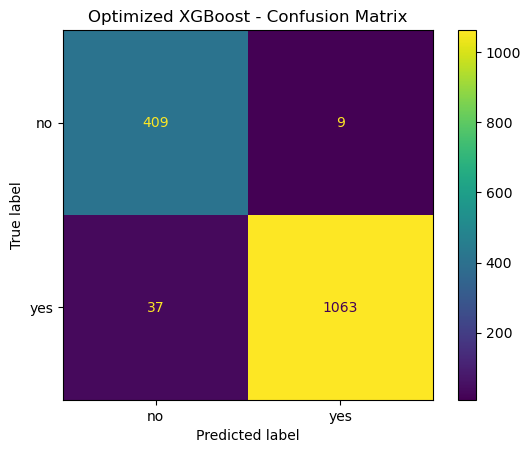

In [32]:
best_xgb = grid_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test_xgb, y_pred_best_xgb))
print("Precision:", precision_score(y_test_xgb, y_pred_best_xgb))
print("Recall   :", recall_score(y_test_xgb, y_pred_best_xgb))
print("F1 Score :", f1_score(y_test_xgb, y_pred_best_xgb))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test_xgb,
        y_pred_best_xgb,
        target_names=["no", "yes"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    y_pred_best_xgb,
    display_labels=["no", "yes"]
)

plt.title("Optimized XGBoost - Confusion Matrix")
plt.show()

### Train vs Test: Overfitting Kontrolü

`max_depth` genişletilmiş aramada da sınırda (2) çıktığı için, modelin eğitim verisini ezberleyip ezberlemediğini kontrol etmek gerekiyor. Eğer train ve test skorları birbirine yakınsa, model iyi genelliyor demektir ve `reg_alpha`/`reg_lambda` (L1/L2) eklemek muhtemelen gereksizdir. Aradaki fark büyükse (örn. train'de ~1.0, test'te belirgin daha düşük), bu net bir overfitting işaretidir ve düzenlileştirme eklemek gerçekten fayda sağlayabilir.

In [33]:
y_pred_train_xgb = best_xgb.predict(X_train_tfidf)

train_f1 = f1_score(y_train_xgb, y_pred_train_xgb)
test_f1 = f1_score(y_test_xgb, y_pred_best_xgb)
train_acc = accuracy_score(y_train_xgb, y_pred_train_xgb)
test_acc = accuracy_score(y_test_xgb, y_pred_best_xgb)

print("=== Optimized XGBoost: Train vs Test ===")
print(f"{'Metrik':<12} {'Train':>8} {'Test':>8} {'Fark':>8}")
print(f"{'Accuracy':<12} {train_acc:>8.4f} {test_acc:>8.4f} {train_acc-test_acc:>8.4f}")
print(f"{'F1 (yes)':<12} {train_f1:>8.4f} {test_f1:>8.4f} {train_f1-test_f1:>8.4f}")

print("\nTrain seti classification report:")
print(classification_report(y_train_xgb, y_pred_train_xgb, target_names=["no", "yes"]))


=== Optimized XGBoost: Train vs Test ===
Metrik          Train     Test     Fark
Accuracy       0.9906   0.9697   0.0209
F1 (yes)       0.9935   0.9788   0.0147

Train seti classification report:
              precision    recall  f1-score   support

          no       0.97      1.00      0.98      1672
         yes       1.00      0.99      0.99      4396

    accuracy                           0.99      6068
   macro avg       0.98      0.99      0.99      6068
weighted avg       0.99      0.99      0.99      6068



**Yorum:** Train-test farkı küçükse (örn. accuracy farkı ~0.02-0.03 veya altı), model bu sığ ağaç yapısıyla zaten iyi genelliyor demektir ve L1/L2 düzenlileştirme araması muhtemelen zaman kaybı olur. Fark büyükse (örn. train'de neredeyse mükemmel, test'te belirgin düşük), `reg_alpha`/`reg_lambda` parametrelerini mevcut GridSearchCV'ye eklemek mantıklı bir sonraki adımdır.

### XGBoost için L1/L2 Düzenlileştirme (`reg_alpha` / `reg_lambda`)

Train-test farkı (~2 puan accuracy, ~1.5 puan F1) orta düzeyde bir overfitting işareti gösterdiği için `reg_alpha` (L1/Lasso benzeri) ve `reg_lambda` (L2/Ridge benzeri) parametreleri denenir. Bu ikisi, lineer modellerdeki gibi katsayılara değil, her yaprağın (leaf) tahmin skoruna uygulanır — büyük yaprak skorlarını cezalandırarak modelin aşırı özgüvenli bölünmeler yapmasını sınırlar. `reg_lambda` XGBoost'ta varsayılan olarak zaten 1'dir (kısmi L2 zaten devrede), `reg_alpha` varsayılanı 0'dır (L1 hiç yok).

**Kapsam notu:** `n_estimators`, `max_depth`, `learning_rate`, `scale_pos_weight` önceki genişletilmiş aramada zaten iyi değerlerde bulunmuştu; bunları tekrar aramak (4 parametreyi `reg_alpha`/`reg_lambda` ile birlikte) kombinasyon sayısını binlerce fit'e çıkarıp pratik olarak çalıştırılamaz hale getirirdi. Bu yüzden o dört parametre önceki en iyi değerlerinde sabitlenip arama sadece düzenlileştirmeye odaklandı. Bu, ortak (joint) bir aramadan daha az kapsamlı olsa da, hesaplama bütçesini asıl merak edilen soruya (düzenlileştirme overfitting'i azaltıyor mu?) yönlendiren bilinçli bir tercihtir.

In [34]:
param_grid_xgb_reg = {
    "n_estimators": [400],        # onceki genisletilmis aramanin en iyisi, sabitlendi
    "max_depth": [2],             # onceki genisletilmis aramanin en iyisi, sabitlendi
    "learning_rate": [0.4],       # onceki genisletilmis aramanin en iyisi, sabitlendi
    "scale_pos_weight": [1],      # onceki genisletilmis aramanin en iyisi, sabitlendi
    "reg_alpha": [0, 0.1, 0.5, 1, 5],
    "reg_lambda": [1, 2, 5, 10]
}

grid_xgb_reg = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb_reg,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_xgb_reg.fit(X_train_tfidf, y_train_xgb)

print("Best Parameters:", grid_xgb_reg.best_params_)
print("Best CV Macro F1:", grid_xgb_reg.best_score_)
print("Karsilastirma icin onceki (duzenlilestirmesiz) CV Macro F1:", grid_xgb.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'learning_rate': 0.4, 'max_depth': 2, 'n_estimators': 400, 'reg_alpha': 0, 'reg_lambda': 1, 'scale_pos_weight': 1}
Best CV Macro F1: 0.9589870242150154
Karsilastirma icin onceki (duzenlilestirmesiz) CV Macro F1: 0.9589870242150154


Düzenlileştirilmiş en iyi model test setinde değerlendirilir ve hem test performansı hem de train-test farkı, düzenlileştirmesiz sürümle karşılaştırılır.

=== Optimized XGBoost + L1/L2: Test ===
Accuracy : 0.9696969696969697
Precision: 0.9916044776119403
Recall   : 0.9663636363636363
F1 Score : 0.9788213627992634

Classification Report:

              precision    recall  f1-score   support

          no       0.92      0.98      0.95       418
         yes       0.99      0.97      0.98      1100

    accuracy                           0.97      1518
   macro avg       0.95      0.97      0.96      1518
weighted avg       0.97      0.97      0.97      1518



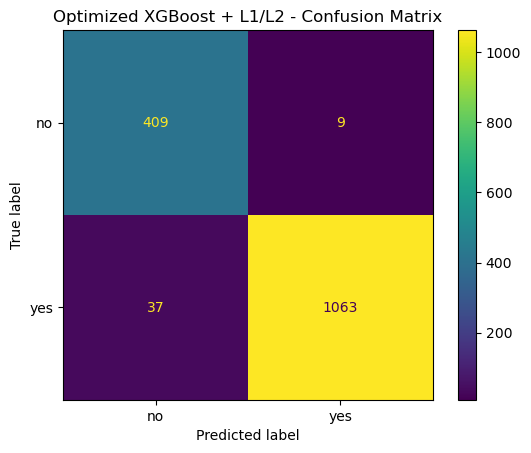


=== Train-Test farki karsilastirmasi ===
Metrik                Duzenlilestirmesiz fark   Duzenlilestirmeli fark
Accuracy                               0.0209                   0.0209
F1 (yes)                               0.0147                   0.0147


In [35]:
best_xgb_reg = grid_xgb_reg.best_estimator_

y_pred_best_xgb_reg = best_xgb_reg.predict(X_test_tfidf)
y_pred_train_xgb_reg = best_xgb_reg.predict(X_train_tfidf)

print("=== Optimized XGBoost + L1/L2: Test ===")
print("Accuracy :", accuracy_score(y_test_xgb, y_pred_best_xgb_reg))
print("Precision:", precision_score(y_test_xgb, y_pred_best_xgb_reg))
print("Recall   :", recall_score(y_test_xgb, y_pred_best_xgb_reg))
print("F1 Score :", f1_score(y_test_xgb, y_pred_best_xgb_reg))
print("\nClassification Report:\n")
print(classification_report(y_test_xgb, y_pred_best_xgb_reg, target_names=["no", "yes"]))

ConfusionMatrixDisplay.from_predictions(
    y_test_xgb, y_pred_best_xgb_reg, display_labels=["no", "yes"]
)
plt.title("Optimized XGBoost + L1/L2 - Confusion Matrix")
plt.show()

train_f1_reg = f1_score(y_train_xgb, y_pred_train_xgb_reg)
test_f1_reg = f1_score(y_test_xgb, y_pred_best_xgb_reg)
train_acc_reg = accuracy_score(y_train_xgb, y_pred_train_xgb_reg)
test_acc_reg = accuracy_score(y_test_xgb, y_pred_best_xgb_reg)

print("\n=== Train-Test farki karsilastirmasi ===")
print(f"{'Metrik':<20} {'Duzenlilestirmesiz fark':>24} {'Duzenlilestirmeli fark':>24}")
print(f"{'Accuracy':<20} {train_acc-test_acc:>24.4f} {train_acc_reg-test_acc_reg:>24.4f}")
print(f"{'F1 (yes)':<20} {train_f1-test_f1:>24.4f} {train_f1_reg-test_f1_reg:>24.4f}")


**Yorum:** Eğer düzenlileştirmeli modelin train-test farkı belirgin şekilde küçüldüyse (overfitting azaldıysa) VE test Macro F1'i düşmediyse, bu model bir sonraki adımda ana karşılaştırma tablosuna (`sonuc_tablosu`) eklenmeye adaydır. Fark küçülmediyse veya test performansı belirgin düştüyse, mevcut düzenlileştirmesiz XGBoost'un (zaten iyi genelleyen, sığ ağaçlı) yapısı tercih edilmeye devam edilmelidir.

### 3. Random Forest

Random Forest için `GridSearchCV` ile hiperparametre araması yapılır: `n_estimators`, `max_depth`, `min_samples_leaf` ve `class_weight` parametreleri taranır.

**Genişletilmiş arama:** İlk taramada en iyi `n_estimators` (300) üst sınırda çıkmıştı; 400'e kadar genişletildiğinde CV skoru pratik olarak değişmedi (doygunluk), bu yüzden `n_estimators` tekrar [200, 300]'e küçültüldü. Bunun yerine hiç denenmemiş olan `max_features` parametresi eklendi — TF-IDF gibi ~11.000 boyutlu ve seyrek bir özellik uzayında, her bölünmede kaç özelliğin değerlendirileceği (varsayılan `"sqrt"` ≈ 105 özellik) sonucu belirgin etkileyebilir. `min_samples_leaf` için bulunan değer (1) zaten bu parametrenin alabileceği en küçük geçerli değer olduğundan (0 geçersizdir), bu bir "sınır sorunu" değildir; aynı şekilde `max_depth` için `None` zaten sınırsız derinliği ifade ettiğinden ek bir üst değere gerek yoktur.

In [36]:
param_grid_rf = {
    "n_estimators": [200, 300],  # 400 denendi, kazanc olmadigi icin kucultuldu (odak: max_features)
    "max_depth": [None, 30],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"],
    "max_features": ["sqrt", "log2", 0.1, 0.3]  # yeni: her bolunmede kac ozellik degerlendirilecek
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=1,          # RF zaten n_jobs=-1 ile paralel calisiyor, ikisini birden -1 yapmayin
    verbose=1
)
grid_rf.fit(X_train_tfidf, y_train)
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Macro F1:", grid_rf.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV Macro F1: 0.9582944214677822


En iyi Random Forest modeli test setinde değerlendirilir ve sonuçlar raporlanır.

Accuracy : 0.969038208168643
Precision: 0.9852534562211982
Recall   : 0.9718181818181818
F1 Score : 0.9784897025171625

Classification Report:

              precision    recall  f1-score   support

          no       0.93      0.96      0.94       418
         yes       0.99      0.97      0.98      1100

    accuracy                           0.97      1518
   macro avg       0.96      0.97      0.96      1518
weighted avg       0.97      0.97      0.97      1518



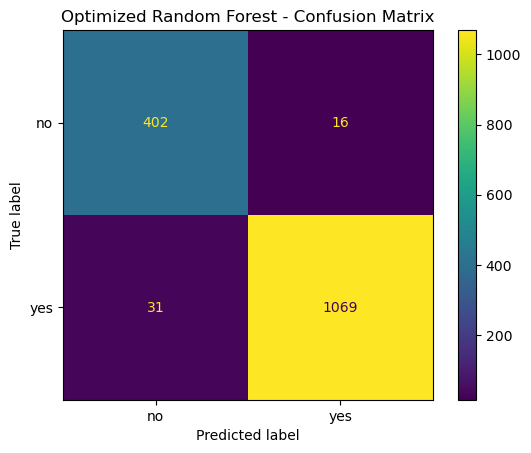

In [37]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_tfidf)
print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_rf, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_rf, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_rf))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_rf,
    labels=["no", "yes"]
)
plt.title("Optimized Random Forest - Confusion Matrix")
plt.show()

**Random Forest optimizasyonu tamamlandı:** `n_estimators`, `max_depth`, `min_samples_leaf`, `class_weight` ve `max_features` parametrelerinin tamamı denendi ve genişletildi. `max_features` için `"sqrt"` (varsayılan) tüm alternatiflere (`"log2"`, `0.1`, `0.3`) karşı kazandı; `n_estimators` 400'e genişletildiğinde CV skorunda pratik bir değişiklik olmadı. Bu, Random Forest için hiperparametre aramasının artık **doygunluğa ulaştığını** ve ek arama yapmanın düşük getirili olacağını gösteriyor — bu model için optimizasyon burada kapatılmıştır.

### 4. Logistic Regression GridSearchCV

Logistic Regression için `GridSearchCV` ile hiperparametre araması yapılır: `C` (düzenlileştirme gücü) ve `class_weight` (sınıf dengesizliği düzeltmesi) parametreleri, 5 katlı çapraz doğrulama ile taranır.

**Genişletilmiş arama:** İlk taramada en iyi `C` değeri (10) aralığın üst sınırında çıkmıştı — bu, gerçek optimumun daha yüksek bir yerde olabileceğine işaret eder. Aralık 20 ve 50'ye kadar genişletildi.

In [38]:
param_grid_lr = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50],  # onceki en iyi (10) sinirda cikmisti, yukari genisletildi
    "class_weight": [None, "balanced"]
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_lr.fit(X_train_tfidf, y_train)
print("Best params:", grid_lr.best_params_)
print("Best CV Macro F1:", grid_lr.best_score_)


Best params: {'C': 50, 'class_weight': 'balanced'}
Best CV Macro F1: 0.947259049010938


GridSearchCV'nin bulduğu en iyi Logistic Regression modeli (`best_estimator_`) test setinde değerlendirilir ve sonuçlar (accuracy, precision, recall, F1, confusion matrix) raporlanır.

Accuracy : 0.9591567852437418
Precision: 0.9752747252747253
Recall   : 0.9681818181818181
F1 Score : 0.9717153284671532

Classification Report:

              precision    recall  f1-score   support

          no       0.92      0.94      0.93       418
         yes       0.98      0.97      0.97      1100

    accuracy                           0.96      1518
   macro avg       0.95      0.95      0.95      1518
weighted avg       0.96      0.96      0.96      1518



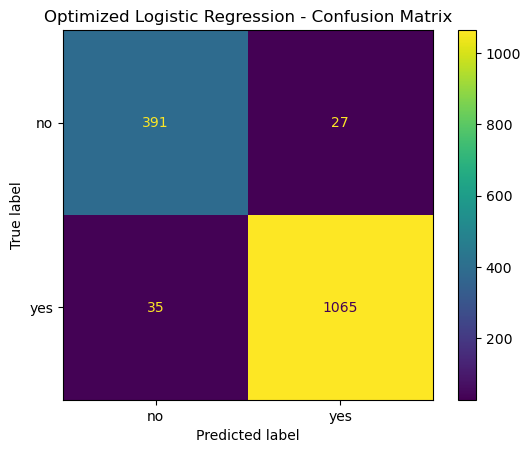

In [39]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_best_lr))
print("Precision:", precision_score(y_test, y_pred_best_lr, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_lr, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_lr, pos_label="yes"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_lr))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_lr,
    labels=["no", "yes"]
)
plt.title("Optimized Logistic Regression - Confusion Matrix")
plt.show()


### 5. Multinomial NB GridSearchCV

Multinomial Naive Bayes için `GridSearchCV` ile `alpha` (Laplace/Lidstone düzgünleştirme parametresi) taranır; küçük `alpha` değerleri modelin eğitim verisindeki nadir kelimelere daha az güvenmesini, büyük değerler ise daha güçlü düzgünleştirme uygulanmasını sağlar. Not: Multinomial NB'de `class_weight` parametresi yoktur, bu yüzden sınıf dengesizliği bu model için `alpha` dışında doğrudan ayarlanamaz.

In [40]:
param_grid_mnb = {
    "alpha": [0.01, 0.05, 0.1, 0.5, 1, 2, 5]
}
grid_mnb = GridSearchCV(
    MultinomialNB(),
    param_grid_mnb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_mnb.fit(X_train_tfidf, y_train)
print("Best params:", grid_mnb.best_params_)
print("Best CV Macro F1:", grid_mnb.best_score_)


Best params: {'alpha': 0.1}
Best CV Macro F1: 0.8670642793714686


GridSearchCV'nin bulduğu en iyi Multinomial NB modeli test setinde değerlendirilir.

Accuracy : 0.9005270092226614
Precision: 0.8944305901911886
Recall   : 0.9781818181818182
F1 Score : 0.934433347807208

Classification Report:

              precision    recall  f1-score   support

          no       0.92      0.70      0.79       418
         yes       0.89      0.98      0.93      1100

    accuracy                           0.90      1518
   macro avg       0.91      0.84      0.86      1518
weighted avg       0.90      0.90      0.90      1518



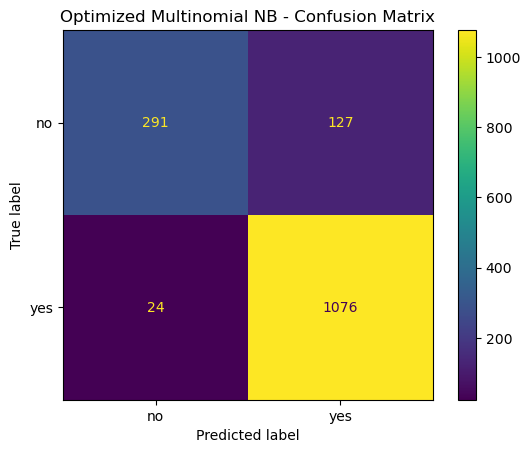

In [41]:
best_mnb = grid_mnb.best_estimator_

y_pred_best_mnb = best_mnb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_best_mnb))
print("Precision:", precision_score(y_test, y_pred_best_mnb, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_mnb, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_mnb, pos_label="yes"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_mnb))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_mnb,
    labels=["no", "yes"]
)
plt.title("Optimized Multinomial NB - Confusion Matrix")
plt.show()


### 6. Complement NB GridSearchCV

Complement Naive Bayes için de aynı şekilde `alpha` parametresi taranır; bu model dengesiz sınıflar için özel olarak tasarlandığından, optimum düzgünleştirme seviyesi Multinomial NB'den farklı çıkabilir.

In [42]:
param_grid_cnb = {
    "alpha": [0.01, 0.05, 0.1, 0.5, 1, 2, 5]
}
grid_cnb = GridSearchCV(
    ComplementNB(),
    param_grid_cnb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_cnb.fit(X_train_tfidf, y_train)
print("Best params:", grid_cnb.best_params_)
print("Best CV Macro F1:", grid_cnb.best_score_)


Best params: {'alpha': 0.05}
Best CV Macro F1: 0.8951600808174177


GridSearchCV'nin bulduğu en iyi Complement NB modeli test setinde değerlendirilir.

Accuracy : 0.9189723320158103
Precision: 0.9311562224183584
Recall   : 0.9590909090909091
F1 Score : 0.9449171518137035

Classification Report:

              precision    recall  f1-score   support

          no       0.88      0.81      0.85       418
         yes       0.93      0.96      0.94      1100

    accuracy                           0.92      1518
   macro avg       0.91      0.89      0.90      1518
weighted avg       0.92      0.92      0.92      1518



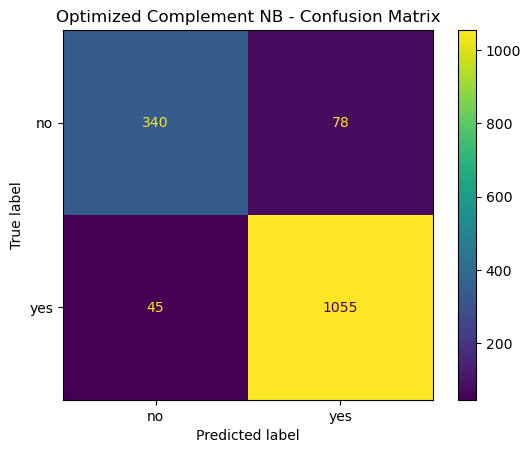

In [43]:
best_cnb = grid_cnb.best_estimator_

y_pred_best_cnb = best_cnb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_best_cnb))
print("Precision:", precision_score(y_test, y_pred_best_cnb, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_cnb, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_cnb, pos_label="yes"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_cnb))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_cnb,
    labels=["no", "yes"]
)
plt.title("Optimized Complement NB - Confusion Matrix")
plt.show()


### 7. NB modelleri için sample_weight (class_weight alternatifi)

Multinomial NB ve Complement NB'de `class_weight` parametresi yoktur, ancak `.fit()` `sample_weight` argümanını kabul eder. Bu, dengesiz sınıflar için manuel bir ağırlıklandırma imkânı sağlar: azınlık sınıfa ("no") daha yüksek ağırlık vererek modelin bu sınıfı ihmal etmesini azaltmayı hedefler. `compute_sample_weight("balanced", y_train)` ile hesaplanan ağırlıklar, aynı `alpha` arama uzayıyla GridSearchCV'ye `fit_params` olarak verilir.

In [44]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight("balanced", y_train)

grid_mnb_sw = GridSearchCV(
    MultinomialNB(),
    param_grid_mnb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_mnb_sw.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
print("Multinomial NB (sample_weight) -- Best params:", grid_mnb_sw.best_params_)
print("Multinomial NB (sample_weight) -- Best CV Macro F1:", grid_mnb_sw.best_score_)

grid_cnb_sw = GridSearchCV(
    ComplementNB(),
    param_grid_cnb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_cnb_sw.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
print("\nComplement NB (sample_weight) -- Best params:", grid_cnb_sw.best_params_)
print("Complement NB (sample_weight) -- Best CV Macro F1:", grid_cnb_sw.best_score_)


Multinomial NB (sample_weight) -- Best params: {'alpha': 2}
Multinomial NB (sample_weight) -- Best CV Macro F1: 0.899836744893696

Complement NB (sample_weight) -- Best params: {'alpha': 2}
Complement NB (sample_weight) -- Best CV Macro F1: 0.900057433710019


Sample_weight ile eğitilmiş en iyi NB modelleri test setinde değerlendirilir ve alpha-only (sample_weight'siz) sürümleriyle doğrudan karşılaştırılır.

=== Multinomial NB (alpha + sample_weight) ===
Accuracy : 0.9156785243741765
Precision: 0.9434306569343066
Recall   : 0.94
F1 Score : 0.941712204007286

Classification Report:

              precision    recall  f1-score   support

          no       0.84      0.85      0.85       418
         yes       0.94      0.94      0.94      1100

    accuracy                           0.92      1518
   macro avg       0.89      0.90      0.89      1518
weighted avg       0.92      0.92      0.92      1518



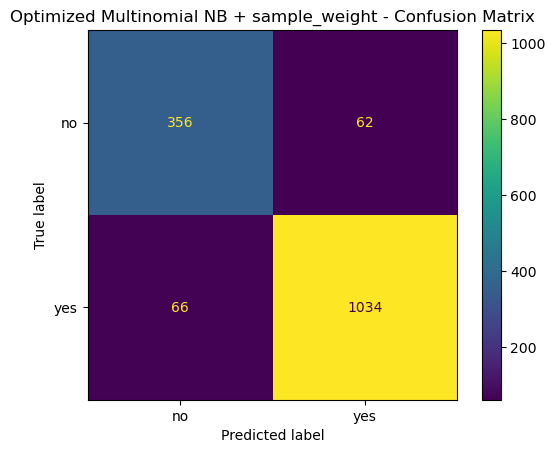



=== Complement NB (alpha + sample_weight) ===
Accuracy : 0.9156785243741765
Precision: 0.9434306569343066
Recall   : 0.94
F1 Score : 0.941712204007286

Classification Report:

              precision    recall  f1-score   support

          no       0.84      0.85      0.85       418
         yes       0.94      0.94      0.94      1100

    accuracy                           0.92      1518
   macro avg       0.89      0.90      0.89      1518
weighted avg       0.92      0.92      0.92      1518



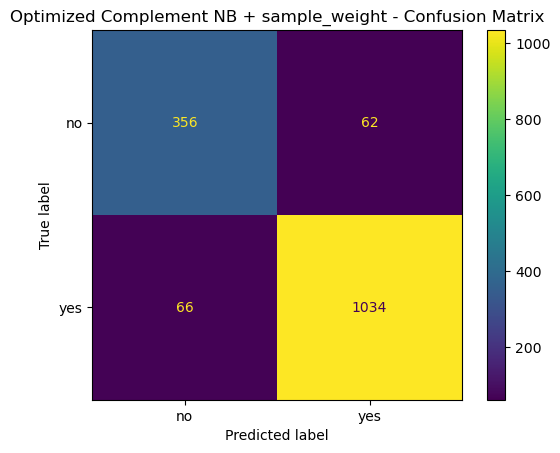

In [45]:
best_mnb_sw = grid_mnb_sw.best_estimator_
best_cnb_sw = grid_cnb_sw.best_estimator_

y_pred_best_mnb_sw = best_mnb_sw.predict(X_test_tfidf)
y_pred_best_cnb_sw = best_cnb_sw.predict(X_test_tfidf)

print("=== Multinomial NB (alpha + sample_weight) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_best_mnb_sw))
print("Precision:", precision_score(y_test, y_pred_best_mnb_sw, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_mnb_sw, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_mnb_sw, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_mnb_sw))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_mnb_sw, labels=["no", "yes"]
)
plt.title("Optimized Multinomial NB + sample_weight - Confusion Matrix")
plt.show()

print("\n\n=== Complement NB (alpha + sample_weight) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_best_cnb_sw))
print("Precision:", precision_score(y_test, y_pred_best_cnb_sw, pos_label="yes"))
print("Recall   :", recall_score(y_test, y_pred_best_cnb_sw, pos_label="yes"))
print("F1 Score :", f1_score(y_test, y_pred_best_cnb_sw, pos_label="yes"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_cnb_sw))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_cnb_sw, labels=["no", "yes"]
)
plt.title("Optimized Complement NB + sample_weight - Confusion Matrix")
plt.show()


Optimizasyon öncesi ve sonrası accuracy ile "no" sınıfı recall değerleri, üç optimize edilen model (SVM, Random Forest, XGBoost) için karşılaştırmalı çubuk grafiklerle gösterilir.

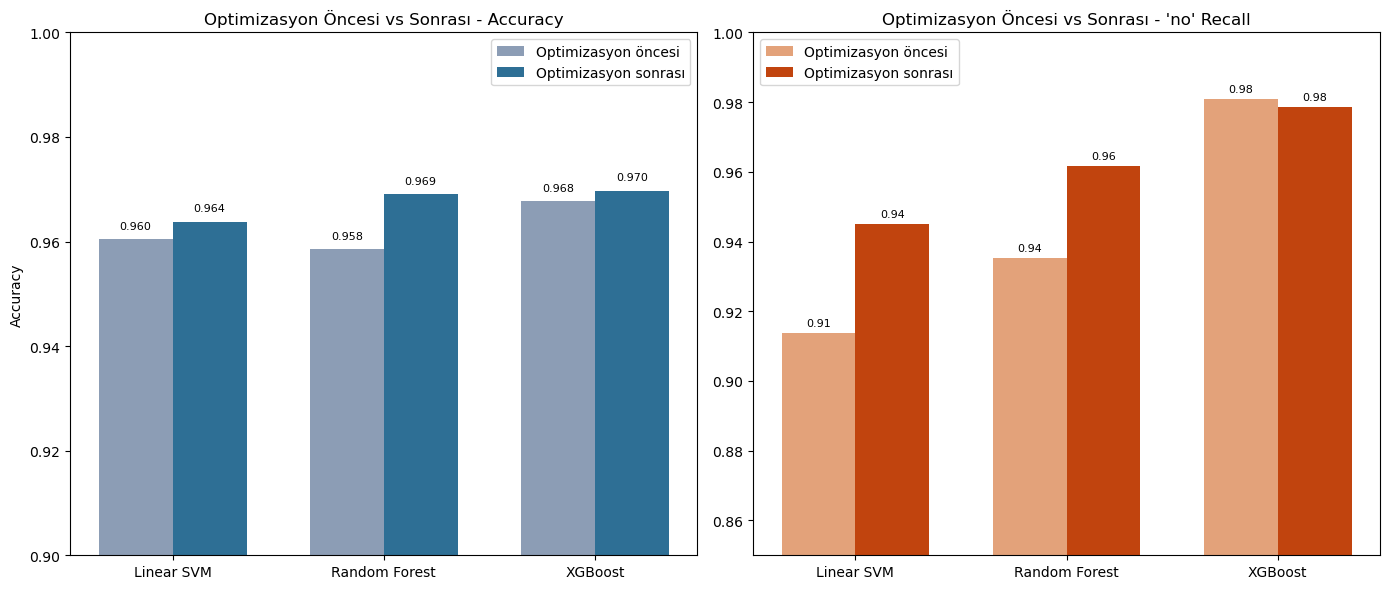

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Optimizasyon oncesi/sonrasi tahminleri karsilastir
karsilastirma = {
    "Linear SVM":    {"once": (y_test, y_pred_svm), "sonra": (y_test, y_pred_best_svm)},
    "Random Forest": {"once": (y_test, y_pred_rf),  "sonra": (y_test, y_pred_best_rf)},
    "XGBoost":       {"once": (y_test_xgb, y_pred_xgb), "sonra": (y_test_xgb, y_pred_best_xgb)},
}

modeller = list(karsilastirma.keys())
once_acc, sonra_acc, once_recall, sonra_recall = [], [], [], []

for isim in modeller:
    for asama, hedef_liste_acc, hedef_liste_recall in [
        ("once", once_acc, once_recall), ("sonra", sonra_acc, sonra_recall)
    ]:
        yt, yp = karsilastirma[isim][asama]
        target_names = ["no", "yes"] if set(np.unique(yt)) == {0, 1} else None
        rapor = classification_report(yt, yp, target_names=target_names, output_dict=True)
        hedef_liste_acc.append(accuracy_score(yt, yp))
        hedef_liste_recall.append(rapor["no"]["recall"])

x = np.arange(len(modeller))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafik 1: Accuracy once/sonra ---
ax1 = axes[0]
b1 = ax1.bar(x - width/2, once_acc, width, label="Optimizasyon öncesi", color="#8c9db5")
b2 = ax1.bar(x + width/2, sonra_acc, width, label="Optimizasyon sonrası", color="#2e6f95")
ax1.set_xticks(x); ax1.set_xticklabels(modeller)
ax1.set_ylim(0.90, 1.0)
ax1.set_ylabel("Accuracy")
ax1.set_title("Optimizasyon Öncesi vs Sonrası - Accuracy")
ax1.legend()
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x()+bar.get_width()/2, h+0.002, f"{h:.3f}", ha="center", fontsize=8)

# --- Grafik 2: "no" recall once/sonra ---
ax2 = axes[1]
b3 = ax2.bar(x - width/2, once_recall, width, label="Optimizasyon öncesi", color="#e3a27a")
b4 = ax2.bar(x + width/2, sonra_recall, width, label="Optimizasyon sonrası", color="#c1440e")
ax2.set_xticks(x); ax2.set_xticklabels(modeller)
ax2.set_ylim(0.85, 1.0)
ax2.set_title("Optimizasyon Öncesi vs Sonrası - 'no' Recall")
ax2.legend()
for bars in (b3, b4):
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x()+bar.get_width()/2, h+0.002, f"{h:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

Optimize edilmiş sekiz model varyantının (SVM, LogReg, RF, XGBoost, iki NB modelinin alpha-only ve alpha+sample_weight sürümleri) accuracy, "no" recall/precision değerlerini bir araya getiren özet bir karşılaştırma tablosu (`sonuc_tablosu`) oluşturulur. Tabloya ayrıca **Macro F1** eklenmiştir: sınıf dağılımı dengesiz olduğu için (yes ≈ çoğunluk sınıfı), yalnızca accuracy'e bakmak yanıltıcı olabilir — Macro F1, her iki sınıfın F1 skorunun ağırlıksız ortalamasını alarak azınlık sınıftaki ("no") performansı da eşit ağırlıkla hesaba katar. Değerler önceki hücrelerdeki gerçek `y_pred_*` değişkenlerinden hesaplanır (sabit/elle girilmiş sayı değildir), böylece notebook yeniden çalıştırıldığında otomatik güncellenir.

In [47]:
def model_metrikleri(model_adi, y_true, y_pred, pos_label="yes", not_metni=""):
    target_names = ["no", "yes"] if set(pd.unique(y_true)) == {0, 1} else None
    rapor = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    no_key = "no"
    return {
        "Model": model_adi,
        "Accuracy": accuracy_score(y_true, y_pred),
        "'no' Recall": rapor[no_key]["recall"],
        "'no' Precision": rapor[no_key]["precision"],
        "Macro F1": rapor["macro avg"]["f1-score"],
        "Not": not_metni,
    }

sonuc_tablosu = pd.DataFrame([
    model_metrikleri("Optimized XGBoost", y_test_xgb, y_pred_best_xgb, pos_label=1,
                      not_metni="En yüksek recall, ama en düşük 'no' precision"),
    model_metrikleri("Optimized Random Forest", y_test, y_pred_best_rf,
                      not_metni="Accuracy'de XGBoost'a yakın, daha dengeli"),
    model_metrikleri("Optimized Linear SVM", y_test, y_pred_best_svm,
                      not_metni="En basit/yorumlanabilir, hâlâ güçlü"),
    model_metrikleri("Optimized Logistic Regression", y_test, y_pred_best_lr,
                      not_metni="Optimizasyonla dengesizlik duzeltmesi (class_weight) denendi"),
    model_metrikleri("Optimized Complement NB", y_test, y_pred_best_cnb,
                      not_metni="Dengesiz veri için tasarlanmış, alpha optimize edildi"),
    model_metrikleri("Optimized Multinomial NB", y_test, y_pred_best_mnb,
                      not_metni="Alpha optimize edildi, ama sinif agirligi ayarlanamiyor"),
    model_metrikleri("Complement NB + sample_weight", y_test, y_pred_best_cnb_sw,
                      not_metni="class_weight yerine sample_weight ile dengesizlik duzeltmesi"),
    model_metrikleri("Multinomial NB + sample_weight", y_test, y_pred_best_mnb_sw,
                      not_metni="class_weight yerine sample_weight ile dengesizlik duzeltmesi"),
])

# Siralama artik Macro F1'e gore -- dengesiz siniflarda accuracy'den daha guvenilir
sonuc_tablosu = sonuc_tablosu.sort_values("Macro F1", ascending=False).reset_index(drop=True)
sonuc_tablosu.round(4)


,Model,Accuracy,'no' Recall,'no' Precision,Macro F1,Not
0,Optimized XGBoost,0.9697,0.9785,0.9170,0.9628,"En yüksek recall, ama en düşük 'no' precision"
1,Optimized Random Forest,0.9690,0.9617,0.9284,0.9616,"Accuracy'de XGBoost'a yakın, daha dengeli"
2,Optimized Linear SVM,0.9638,0.9450,0.9251,0.9549,"En basit/yorumlanabilir, hâlâ güçlü"
3,Optimized Logistic Regression,0.9592,0.9354,0.9178,0.9491,Optimizasyonla dengesizlik duzeltmesi (class_w...
4,Optimized Complement NB,0.9190,0.8134,0.8831,0.8959,"Dengesiz veri için tasarlanmış, alpha optimize..."
5,Complement NB + sample_weight,0.9157,0.8517,0.8436,0.8947,class_weight yerine sample_weight ile dengesiz...
6,Multinomial NB + sample_weight,0.9157,0.8517,0.8436,0.8947,class_weight yerine sample_weight ile dengesiz...
7,Optimized Multinomial NB,0.9005,0.6962,0.9238,0.8642,"Alpha optimize edildi, ama sinif agirligi ayar..."


### ROC ve Precision-Recall Eğrileri

Yukarıdaki tabloya göre **Macro F1'i en yüksek olan optimize model** otomatik olarak seçilir ve bu model için eşik-bağımsız iki performans eğrisi çizilir:

- **ROC Eğrisi (AUC):** modelin farklı karar eşiklerinde sınıfları ne kadar iyi ayırt ettiğini tek bir sayıya indirger.
- **Precision-Recall Eğrisi:** sınıflar dengesiz olduğu için (`yes` çoğunlukta), çoğu zaman ROC'tan daha bilgilendirici kabul edilir; azınlık sınıfa (`no`) odaklanmak için `pos_label="no"` ile çizilmiştir.

ROC/PR icin secilen model: Optimized XGBoost | Macro F1: 0.9628


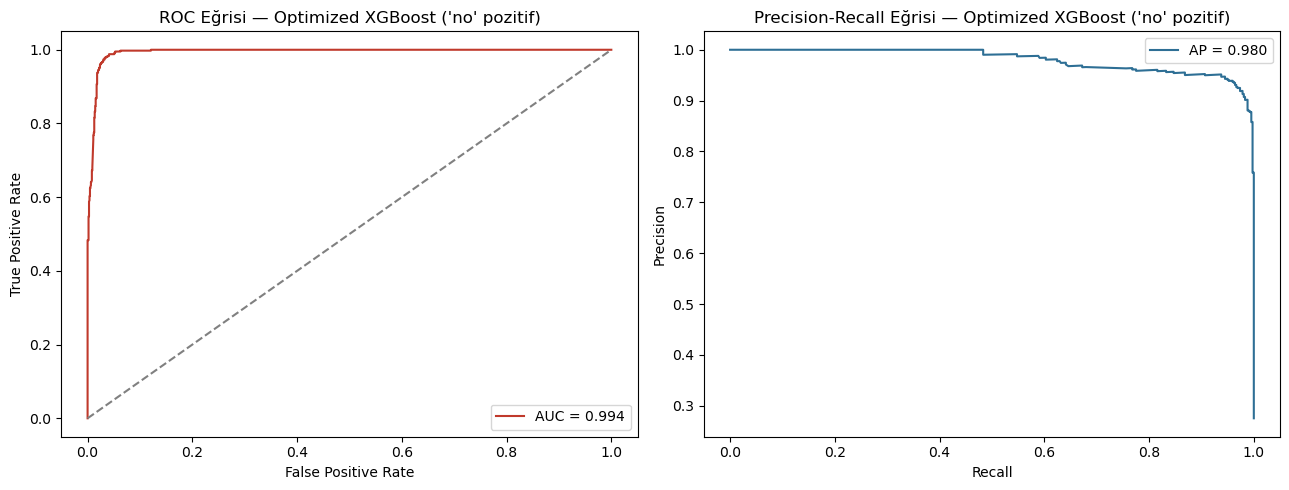

In [48]:
# En iyi modeli (Macro F1'e gore) sonuc_tablosu'ndan otomatik sec
en_iyi_model_adi = sonuc_tablosu.iloc[0]["Model"]
print("ROC/PR icin secilen model:", en_iyi_model_adi, "| Macro F1:", round(sonuc_tablosu.iloc[0]["Macro F1"], 4))

model_obj_map = {
    "Optimized XGBoost": (best_xgb, y_test_xgb),
    "Optimized Random Forest": (best_rf, y_test),
    "Optimized Linear SVM": (best_svm, y_test),
    "Optimized Logistic Regression": (best_lr, y_test),
    "Optimized Complement NB": (best_cnb, y_test),
    "Optimized Multinomial NB": (best_mnb, y_test),
    "Complement NB + sample_weight": (best_cnb_sw, y_test),
    "Multinomial NB + sample_weight": (best_mnb_sw, y_test),
}

en_iyi_model, en_iyi_y_true = model_obj_map[en_iyi_model_adi]
# ROC/PR icin "no" sinifi pozitif etiket olarak alinir (azinlik sinifi, daha bilgilendirici)
# XGBoost 0/1 etiketli oldugu icin "no" siniftaki gibi davranmak istiyorsak once ceviri gerekir
if en_iyi_model_adi == "Optimized XGBoost":
    # XGBoost'ta 0 = "no", 1 = "yes" -- "no" sinifini pozitif almak icin etiketleri ters cevirelim
    proba = en_iyi_model.predict_proba(X_test_tfidf)[:, 0]  # "no" (0) sinifi olasiligi
    y_true_no = (en_iyi_y_true == 0).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fpr, tpr, _ = roc_curve(y_true_no, proba)
    axes[0].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="#c0392b")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Eğrisi — {en_iyi_model_adi} ('no' pozitif)")
    axes[0].legend()

    prec, rec, _ = precision_recall_curve(y_true_no, proba)
    ap_skoru = average_precision_score(y_true_no, proba)
    axes[1].plot(rec, prec, color="#2e6f95", label=f"AP = {ap_skoru:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall Eğrisi — {en_iyi_model_adi} ('no' pozitif)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    RocCurveDisplay.from_estimator(en_iyi_model, X_test_tfidf, en_iyi_y_true, pos_label="no", ax=axes[0])
    axes[0].set_title(f"ROC Eğrisi — {en_iyi_model_adi} ('no' pozitif)")

    PrecisionRecallDisplay.from_estimator(en_iyi_model, X_test_tfidf, en_iyi_y_true, pos_label="no", ax=axes[1])
    axes[1].set_title(f"Precision-Recall Eğrisi — {en_iyi_model_adi} ('no' pozitif)")
    plt.tight_layout()
    plt.show()


## Karar Eşiği (Threshold) Optimizasyonu

Şimdiye kadarki tüm modeller varsayılan 0.5 karar eşiğini (ya da `decision_function` için 0 sınırını) kullanıyordu. Ama dengesiz veri setlerinde bu eşik nadiren optimaldir. **Önemli metodolojik nokta:** en iyi eşiği doğrudan test setinde aramak, test setini bir hiperparametre gibi kullanmak anlamına gelir ve sonucu iyimser gösterebilir (veri sızıntısı). Bunun yerine eşik, eğitim verisinin `cross_val_predict` ile elde edilen 5-katlı çapraz-doğrulanmış (out-of-fold) tahminlerinde aranır; test seti yalnızca bulunan sabit eşikle **tek seferlik nihai değerlendirme** için kullanılır. Model destekliyorsa `predict_proba`, desteklemiyorsa (örn. Linear SVM) `decision_function` kullanılır.

In [49]:
import numpy as np
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

# ---- 1) Esik SADECE egitim verisinin capraz-dogrulanmis (out-of-fold) tahminlerinde araniyor ----
#     Test setine bu asamada hic dokunulmuyor.
if en_iyi_model_adi == "Optimized XGBoost":
    oof_proba = cross_val_predict(
        clone(en_iyi_model), X_train_tfidf, y_train_xgb, cv=5, method="predict_proba", n_jobs=-1
    )[:, 0]
    y_train_no_thr = (y_train_xgb == 0).astype(int)
    varsayilan_esik = 0.5
elif hasattr(en_iyi_model, "predict_proba"):
    oof_proba_full = cross_val_predict(
        clone(en_iyi_model), X_train_tfidf, y_train, cv=5, method="predict_proba", n_jobs=-1
    )
    classes = list(en_iyi_model.classes_)
    no_idx = classes.index("no")
    oof_proba = oof_proba_full[:, no_idx]
    y_train_no_thr = (y_train == "no").astype(int)
    varsayilan_esik = 0.5
else:
    # LinearSVC gibi sadece decision_function sunan modeller icin
    oof_ham = cross_val_predict(
        clone(en_iyi_model), X_train_tfidf, y_train, cv=5, method="decision_function", n_jobs=-1
    )
    classes = list(en_iyi_model.classes_)
    oof_proba = -oof_ham if classes[1] == "yes" else oof_ham
    y_train_no_thr = (y_train == "no").astype(int)
    varsayilan_esik = 0.0  # decision_function=0 sinir noktasidir

precision_no, recall_no, thresholds = precision_recall_curve(y_train_no_thr, oof_proba)
f1_no = 2 * precision_no * recall_no / (precision_no + recall_no + 1e-12)
en_iyi_thr_idx = int(np.argmax(f1_no[:-1]))  # thresholds dizisi 1 eksik uzunlukta
en_iyi_esik = thresholds[en_iyi_thr_idx]

print(f"Model: {en_iyi_model_adi}")
print("Esik, egitim verisinin 5-katli capraz-dogrulanmis (out-of-fold) tahminleri uzerinde araniyor")
print("(test seti bu asamada kullanilmiyor).")
print(f"'no' sinifi F1'ini maksimize eden esik (egitim CV): {en_iyi_esik:.4f}  (varsayilan: {varsayilan_esik})")
print(f"Egitim CV'sindeki bu esikte -> Precision: {precision_no[en_iyi_thr_idx]:.4f}  "
      f"Recall: {recall_no[en_iyi_thr_idx]:.4f}  F1: {f1_no[en_iyi_thr_idx]:.4f}")

# ---- 2) Bulunan sabit esik, TEST setinde SADECE BIR KEZ nihai degerlendirme icin kullanilir ----
if en_iyi_model_adi == "Optimized XGBoost":
    skor_no_test = en_iyi_model.predict_proba(X_test_tfidf)[:, 0]
    y_true_no_thr = (en_iyi_y_true == 0).astype(int)
elif hasattr(en_iyi_model, "predict_proba"):
    classes = list(en_iyi_model.classes_)
    no_idx = classes.index("no")
    skor_no_test = en_iyi_model.predict_proba(X_test_tfidf)[:, no_idx]
    y_true_no_thr = (en_iyi_y_true == "no").astype(int)
else:
    classes = list(en_iyi_model.classes_)
    ham_skor = en_iyi_model.decision_function(X_test_tfidf)
    skor_no_test = -ham_skor if classes[1] == "yes" else ham_skor
    y_true_no_thr = (en_iyi_y_true == "no").astype(int)

varsayilan_tahmin_no = (skor_no_test >= varsayilan_esik).astype(int)
yeni_tahmin_no = (skor_no_test >= en_iyi_esik).astype(int)

print("\n--- TEST setinde varsayilan esik ile classification report ('no' pozitif kabul edilerek) ---")
print(classification_report(y_true_no_thr, varsayilan_tahmin_no, target_names=["diger", "no"]))
print("--- TEST setinde egitim-CV'siyle bulunan esikle classification report ('no' pozitif kabul edilerek) ---")
print(classification_report(y_true_no_thr, yeni_tahmin_no, target_names=["diger", "no"]))


Model: Optimized XGBoost
Esik, egitim verisinin 5-katli capraz-dogrulanmis (out-of-fold) tahminleri uzerinde araniyor
(test seti bu asamada kullanilmiyor).
'no' sinifi F1'ini maksimize eden esik (egitim CV): 0.6404  (varsayilan: 0.5)
Egitim CV'sindeki bu esikte -> Precision: 0.9395  Recall: 0.9474  F1: 0.9434

--- TEST setinde varsayilan esik ile classification report ('no' pozitif kabul edilerek) ---
              precision    recall  f1-score   support

       diger       0.99      0.97      0.98      1100
          no       0.92      0.98      0.95       418

    accuracy                           0.97      1518
   macro avg       0.95      0.97      0.96      1518
weighted avg       0.97      0.97      0.97      1518

--- TEST setinde egitim-CV'siyle bulunan esikle classification report ('no' pozitif kabul edilerek) ---
              precision    recall  f1-score   support

       diger       0.99      0.97      0.98      1100
          no       0.93      0.96      0.95       418



**Yorum:** Eşik, eğitim verisinin çapraz-doğrulanmış tahminlerinde bulunduğu ve test setine yalnızca tek seferlik nihai değerlendirme için uygulandığı için, buradaki karşılaştırma test setini "görmeden" elde edilmiş adil bir tahmindir. Optimize edilmiş eşikteki F1, varsayılan eşikten belirgin şekilde yüksekse, modelin gerçek dünyada 0.5 yerine bu yeni eşikle devreye alınması önerilir. Fark küçükse, model zaten dengesizliğe karşı (GridSearchCV ile bulunan `class_weight`/`scale_pos_weight` sayesinde) makul ölçüde dayanıklı demektir. Not: `cross_val_predict` modelinizi 5 kez daha eğittiği için bu hücre önceki sürüme göre biraz daha uzun sürebilir.

##  Model Hata Analizi

Herhangi bir modelin tahminlerini analiz eden genel amaçlı bir fonksiyon (`hata_analizi_yap`) tanımlanır: yanlış tahmin sayısını, yanlış sınıflandırılan metinleri, ve False Positive/False Negative örneklerini raporlar. Bu fonksiyon, kod tekrarını önlemek amacıyla her model için tekrar tekrar çağrılabilir.

In [50]:
def hata_analizi_yap(model_adi, y_pred):
    hatali_mask = (y_test.values != y_pred)
    hata_df = pd.DataFrame({
        "clean_text": X_test_text.values[hatali_mask],
        "gercek": y_test.values[hatali_mask],
        "tahmin": y_pred[hatali_mask]
    })

    # 1) Yanlis tahminlerin sayisi
    print(f"=== {model_adi} ===")
    print("Yanlış tahmin sayısı:", len(hata_df))

    # 2) Yanlis siniflandirilan metinler
    print("\nYanlış sınıflandırılan metinler:")
    display(hata_df[["clean_text", "gercek", "tahmin"]].head(10))

    # 3) False Positive ornek (gercekte no, tahmin yes)
    fp = hata_df[(hata_df["gercek"] == "no") & (hata_df["tahmin"] == "yes")]
    print("\nFalse Positive örnek (gerçekte haber, dezenformasyon sanılmış):")
    display(fp[["clean_text"]].head(5))

    # 4) False Negative ornek (gercekte yes, tahmin no)
    fn = hata_df[(hata_df["gercek"] == "yes") & (hata_df["tahmin"] == "no")]
    print("\nFalse Negative örnek (gerçekte dezenformasyon, haber sanılmış):")
    display(fn[["clean_text"]].head(5))

    return hata_df

### SVM

`hata_analizi_yap` fonksiyonu, optimize edilmiş Linear SVM modelinin tahminlerine uygulanır.

In [51]:
hata_svm = hata_analizi_yap("Linear SVM (optimize)", y_pred_best_svm)

=== Linear SVM (optimize) ===
Yanlış tahmin sayısı: 55

Yanlış sınıflandırılan metinler:


,clean_text,gercek,tahmin
0,edge of armageddon : why does one of the world...,no,yes
1,"moldova votes in election, eu re",yes,no
2,state media of the russian federation hid the ...,no,yes
3,kyiv denied the russian federation's claim abo...,no,yes
4,kyiv: allies should not succumb to russian bla...,no,yes
5,germany refuses to call ukraine its ally. germ...,yes,no
6,"in cannes, pegah ahangrani dedicated his film ...",no,yes
7,the russian army has placed equipment and weap...,no,yes
8,the western principle of divide and rule is a ...,no,yes
9,satisfying tungsten hunger kazakhstan is being...,yes,no



False Positive örnek (gerçekte haber, dezenformasyon sanılmış):


,clean_text
0,edge of armageddon : why does one of the world...
2,state media of the russian federation hid the ...
3,kyiv denied the russian federation's claim abo...
4,kyiv: allies should not succumb to russian bla...
6,"in cannes, pegah ahangrani dedicated his film ..."



False Negative örnek (gerçekte dezenformasyon, haber sanılmış):


,clean_text
1,"moldova votes in election, eu re"
5,germany refuses to call ukraine its ally. germ...
9,satisfying tungsten hunger kazakhstan is being...
10,russian officials say ukraine again strikes dr...
12,ukraine war briefing: zelenskyy and merz welco...


### Random Forest

`hata_analizi_yap` fonksiyonu, optimize edilmiş Random Forest modelinin tahminlerine uygulanır.

In [52]:
hata_rf = hata_analizi_yap("Random Forest (optimize)", y_pred_best_rf)

=== Random Forest (optimize) ===
Yanlış tahmin sayısı: 47

Yanlış sınıflandırılan metinler:


,clean_text,gercek,tahmin
0,"moldova votes in election, eu re",yes,no
1,"kremlin announces ""humanitarian corridors to r...",yes,no
2,the western principle of divide and rule is a ...,no,yes
3,satisfying tungsten hunger kazakhstan is being...,yes,no
4,"zelenskyy is banning russian language, culture...",yes,no
5,: enemy tg-channels are spreading photo of a d...,no,yes
6,ukraine war briefing: zelenskyy and merz welco...,yes,no
7,the russian guard continues to transfer unclai...,yes,no
8,"russian liberation of lysychansk, severodonets...",yes,no
9,moldova is preparing for a new war against tra...,yes,no



False Positive örnek (gerçekte haber, dezenformasyon sanılmış):


,clean_text
2,the western principle of divide and rule is a ...
5,: enemy tg-channels are spreading photo of a d...
10,sad statistics and the negative example of ukr...
12,the ukrainian foreign ministry building suffer...
17,we want to see him in ukraine : zelenskyy hope...



False Negative örnek (gerçekte dezenformasyon, haber sanılmış):


,clean_text
0,"moldova votes in election, eu re"
1,"kremlin announces ""humanitarian corridors to r..."
3,satisfying tungsten hunger kazakhstan is being...
4,"zelenskyy is banning russian language, culture..."
6,ukraine war briefing: zelenskyy and merz welco...


### XGBoost

XGBoost'un hedef değişkeni 0/1 olarak kodlandığından ("no"/"yes" değil), bu model için ayrı bir hata analizi fonksiyonu (`hata_analizi_yap_xgb`) tanımlanıp optimize edilmiş XGBoost modeline uygulanır.

In [53]:
def hata_analizi_yap_xgb(model_adi, y_pred, y_true, X_metin):
    hatali_mask = (y_true.values != y_pred)
    hata_df = pd.DataFrame({
        "clean_text": X_metin.values[hatali_mask],
        "gercek": y_true.values[hatali_mask],
        "tahmin": y_pred[hatali_mask]
    })
    print(f"=== {model_adi} ===")
    print("Yanlış tahmin sayısı:", len(hata_df))
    display(hata_df.head(10))
    fp = hata_df[(hata_df["gercek"]==0)&(hata_df["tahmin"]==1)]
    fn = hata_df[(hata_df["gercek"]==1)&(hata_df["tahmin"]==0)]
    print("\nFalse Positive örnek:")
    display(fp[["clean_text"]].head(5))
    print("\nFalse Negative örnek:")
    display(fn[["clean_text"]].head(5))
    return hata_df

hata_xgb = hata_analizi_yap_xgb("XGBoost (optimize)", y_pred_best_xgb, y_test_xgb, X_test_text)

=== XGBoost (optimize) ===
Yanlış tahmin sayısı: 46


,clean_text,gercek,tahmin
0,"moldova votes in election, eu re",1,0
1,kyiv denied the russian federation's claim abo...,0,1
2,nato condemns russia's recklessness,0,1
3,"kremlin announces ""humanitarian corridors to r...",1,0
4,the appearance of f-16s in ukraine will not pl...,1,0
5,ukraine tirelessly working to produce either a...,1,0
6,the western principle of divide and rule is a ...,0,1
7,satisfying tungsten hunger kazakhstan is being...,1,0
8,"zelenskyy is banning russian language, culture...",1,0
9,the russian guard continues to transfer unclai...,1,0



False Positive örnek:


,clean_text
1,kyiv denied the russian federation's claim abo...
2,nato condemns russia's recklessness
6,the western principle of divide and rule is a ...
23,we want to see him in ukraine : zelenskyy hope...
24,putin resisted and decided to fight on - revie...



False Negative örnek:


,clean_text
0,"moldova votes in election, eu re"
3,"kremlin announces ""humanitarian corridors to r..."
4,the appearance of f-16s in ukraine will not pl...
5,ukraine tirelessly working to produce either a...
7,satisfying tungsten hunger kazakhstan is being...


## 20. Özellik Önem Analizi

## Linear SVM

Linear SVM modelinin `coef_` (katsayı) değerleri incelenir: pozitif katsayılı kelimeler "yes" (dezenformasyon), negatif katsayılı kelimeler "no" (gerçek haber) sınıfını işaret eder. SVM doğrusal bir model olduğu için bu katsayılar doğrudan yorumlanabilir.

In [54]:
import numpy as np

coefs = best_svm.coef_[0]
order = np.argsort(coefs)

print("Linear SVM - 'yes' (dezenformasyon) yönünde en güçlü 12 özellik:")
for i in order[-12:][::-1]:
    print(f"  {feature_names[i]:20s} {coefs[i]:.3f}")

print("\nLinear SVM - 'no' (gerçek haber) yönünde en güçlü 12 özellik:")
for i in order[:12]:
    print(f"  {feature_names[i]:20s} {coefs[i]:.3f}")

Linear SVM - 'yes' (dezenformasyon) yönünde en güçlü 12 özellik:
  propaganda           6.278
  fake                 5.607
  claims               5.486
  allegedly            5.263
  alleged              4.407
  claim                3.868
  fakes                3.479
  rumors               3.243
  western              2.945
  west                 2.892
  reportedly           2.793
  claimed              2.734

Linear SVM - 'no' (gerçek haber) yönünde en güçlü 12 özellik:
  university           -2.590
  statistics           -2.333
  scientific           -1.855
  confirmed            -1.818
  cartel               -1.696
  stated ukrainian     -1.660
  official statements  -1.523
  war briefing         -1.521
  published            -1.459
  monaco               -1.447
  drones               -1.441
  experience           -1.440


## Random Forest

Random Forest modelinin `feature_importances_` değerleri incelenir. Bu metrik yönsüzdür (sadece genel ayırt edicilik gücünü gösterir, hangi sınıfa işaret ettiğini değil).

In [55]:
imp_rf = best_rf.feature_importances_
order_rf = np.argsort(imp_rf)[::-1]

print("Random Forest - en önemli 15 özellik (YÖNSÜZ - sadece genel ayırt edicilik):")
for i in order_rf[:15]:
    print(f"  {feature_names[i]:20s} {imp_rf[i]:.4f}")

Random Forest - en önemli 15 özellik (YÖNSÜZ - sadece genel ayırt edicilik):
  propaganda           0.0386
  ukrainian            0.0250
  fake                 0.0250
  ukraine              0.0228
  claims               0.0214
  west                 0.0181
  allegedly            0.0179
  western              0.0165
  russia               0.0139
  russian              0.0127
  alleged              0.0103
  military             0.0096
  regime               0.0096
  fakes                0.0089
  conflict             0.0086


## XGBoost

En iyi model olan XGBoost'un (`best_xgb`) `feature_importances_` değerleri incelenir. Random Forest'takiyle aynı şekilde bu metrik de yönsüzdür (bir kelimenin genel ayırt edicilik gücünü gösterir, "yes" mi "no" mu yönünde olduğunu değil). Varsayılan `importance_type="gain"` kullanılır: bir özelliğin ağaçlardaki bölünmelerde ortalama ne kadar performans kazancı (impurity azalması) sağladığını ölçer.

In [56]:
imp_xgb = best_xgb.feature_importances_
order_xgb = np.argsort(imp_xgb)[::-1]

print("XGBoost - en önemli 15 özellik (YÖNSÜZ - sadece genel ayırt edicilik, importance_type='gain'):")
for i in order_xgb[:15]:
    print(f"  {feature_names[i]:20s} {imp_xgb[i]:.4f}")


XGBoost - en önemli 15 özellik (YÖNSÜZ - sadece genel ayırt edicilik, importance_type='gain'):
  west                 0.0296
  ministry defense     0.0280
  ukrainian            0.0250
  ukraine              0.0245
  kyiv                 0.0239
  propaganda           0.0234
  russia               0.0225
  western              0.0221
  russian              0.0219
  drones               0.0194
  fake                 0.0191
  regime               0.0175
  military             0.0171
  claims               0.0157
  allegedly            0.0154


**Yorum:** Bu sıralamanın Linear SVM ve Random Forest'ta bulunan en güçlü kelimelerle (örn. "propaganda", "fake", "claims", "allegedly") ne kadar örtüştüğüne bakmak, modeller arasında tutarlı bir sinyal olup olmadığını gösterir — üç farklı model ailesi (lineer, bagging, boosting) aynı kelimelere yöneliyorsa, bu bulgunun veri setine özgü bir yapaylık değil, gerçek bir dilsel örüntü olduğuna dair güveni artırır.

## Multinomial NB

Multinomial Naive Bayes'in `feature_log_prob_` değerleri üzerinden, "yes" ve "no" sınıfları arasındaki log-olasılık farkı hesaplanarak en ayırt edici kelimeler (SVM'deki katsayı mantığına benzer şekilde, yönlü olarak) belirlenir.

In [57]:
yes_idx = list(mnb_model.classes_).index("yes")
no_idx = list(mnb_model.classes_).index("no")
diff_mnb = mnb_model.feature_log_prob_[yes_idx] - mnb_model.feature_log_prob_[no_idx]
order_mnb = np.argsort(diff_mnb)

print("Multinomial NB - 'yes' yönünde en güçlü 12 özellik:")
for i in order_mnb[-12:][::-1]:
    print(f"  {feature_names[i]:20s} {diff_mnb[i]:.3f}")

print("\nMultinomial NB - 'no' yönünde en güçlü 12 özellik:")
for i in order_mnb[:12]:
    print(f"  {feature_names[i]:20s} {diff_mnb[i]:.3f}")

Multinomial NB - 'yes' yönünde en güçlü 12 özellik:
  propaganda           3.560
  fake                 3.160
  west                 2.910
  western              2.902
  regime               2.893
  allegedly            2.844
  claims               2.813
  russian propaganda   2.659
  kyiv regime          2.617
  fakes                2.565
  polish               2.564
  spreading            2.386

Multinomial NB - 'no' yönünde en güçlü 12 özellik:
  war briefing         -3.189
  university           -3.136
  statistics           -2.806
  bbc news             -2.706
  wildberries          -2.684
  fedorov              -2.596
  refinery             -2.449
  state university     -2.449
  scientific           -2.431
  xi                   -2.427
  schr                 -2.393
  schr der             -2.393


## Sorular

### 1. Dezenformasyon Hangi Konularda Yayılıyor?


Soru 1: Dezenformasyonun hangi haber kategorilerinde (news_type) yoğunlaştığı incelenir. Kategori büyüklükleri çok dengesiz olduğundan, yalnızca yeterli örneklemi olan (n≥30) kategoriler güvenilir kabul edilir ve iki panelli bir grafikte (hacim + oran) gösterilir.

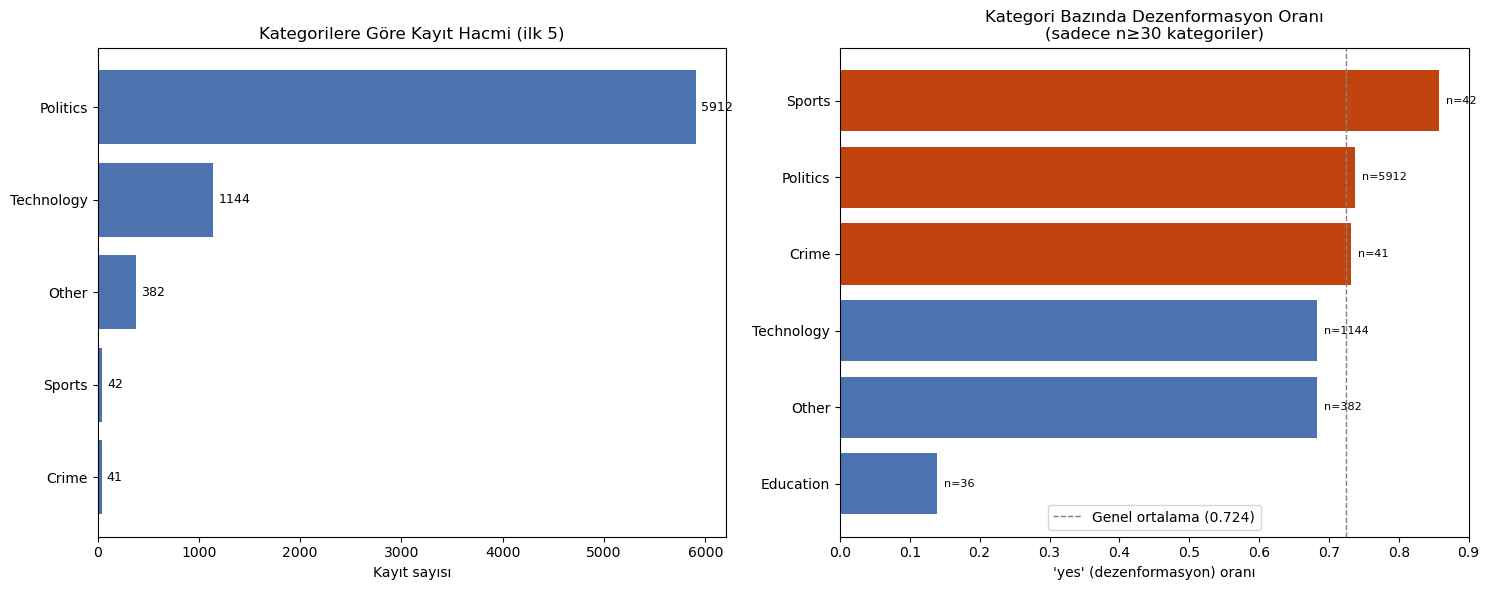

In [58]:
import matplotlib.pyplot as plt
import numpy as np

kategori_ozet = df_clean.groupby("news_type")["is_disinformation"].agg(
    toplam="count",
    yes_orani=lambda x: (x == "yes").mean()
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: hacim (ilk 5 kategori)
ax1 = axes[0]
top5 = kategori_ozet.sort_values("toplam", ascending=False).head(5).sort_values("toplam")
ax1.barh(top5["news_type"], top5["toplam"], color="#4C72B0")
ax1.set_xlabel("Kayıt sayısı")
ax1.set_title("Kategorilere Göre Kayıt Hacmi (ilk 5)")
for i, (v, kat) in enumerate(zip(top5["toplam"], top5["news_type"])):
    ax1.text(v + 50, i, str(v), va="center", fontsize=9)

# Panel 2: yes orani, sadece n>=30 kategoriler
ax2 = axes[1]
guvenilir = kategori_ozet[kategori_ozet["toplam"] >= 30].sort_values("yes_orani")
genel_ortalama = (df_clean["is_disinformation"] == "yes").mean()
colors = ["#c1440e" if o > genel_ortalama else "#4C72B0" for o in guvenilir["yes_orani"]]
bars = ax2.barh(guvenilir["news_type"], guvenilir["yes_orani"], color=colors)
ax2.axvline(genel_ortalama, color="gray", linestyle="--", linewidth=1,
            label=f"Genel ortalama ({genel_ortalama:.3f})")
ax2.set_xlabel("'yes' (dezenformasyon) oranı")
ax2.set_title("Kategori Bazında Dezenformasyon Oranı\n(sadece n≥30 kategoriler)")
ax2.legend()
for bar, n in zip(bars, guvenilir["toplam"]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"n={n}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### 2. Dezenformasyon içeren metinler ile içermeyen metinlerin uzunlukları arasında bir fark var mı?


Soru 2: Dezenformasyon içeren ve içermeyen metinlerin uzunlukları karşılaştırılır (boxplot ve histogram). Bu analiz, projedeki en çarpıcı bulgulardan birini ortaya çıkarır: dezenformasyon metinleri gerçek haberlerden ortalama 4 kat daha uzundur.

no  ort. uzunluk: 81.6 | medyan: 74.0
yes ort. uzunluk: 356.4 | medyan: 310.0


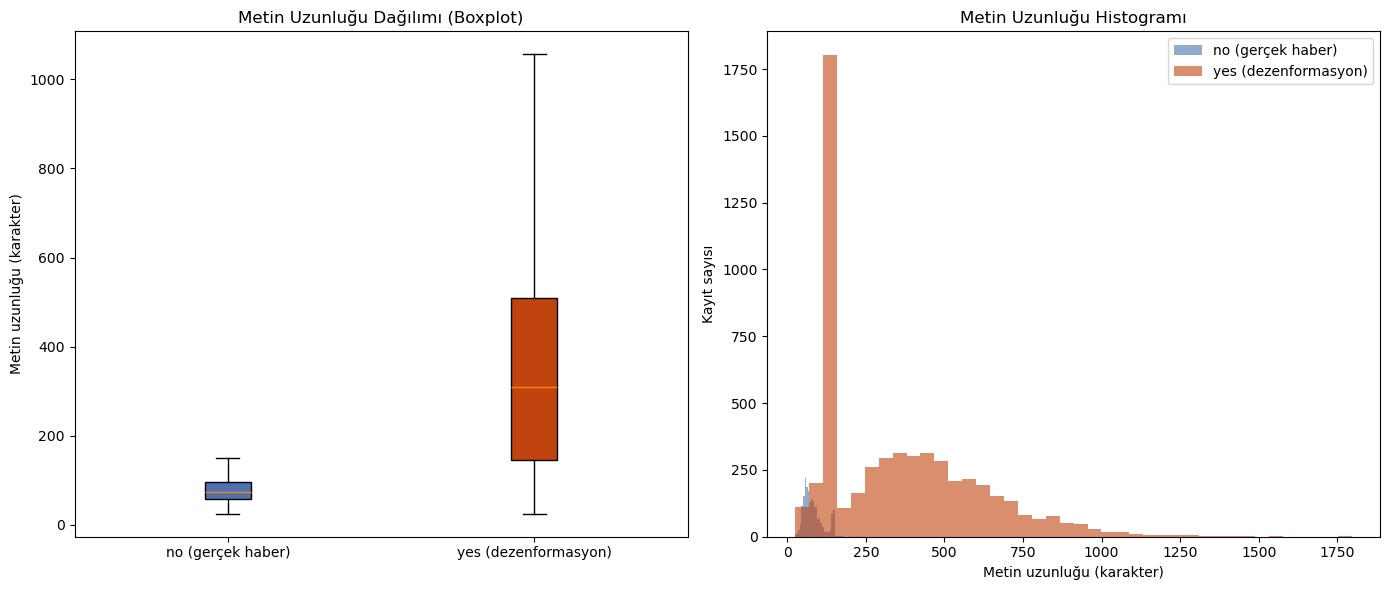

In [59]:
import matplotlib.pyplot as plt

df_clean["uzunluk"] = df_clean["clean_text"].str.len()

no_uz = df_clean[df_clean["is_disinformation"] == "no"]["uzunluk"]
yes_uz = df_clean[df_clean["is_disinformation"] == "yes"]["uzunluk"]

print("no  ort. uzunluk:", no_uz.mean().round(1), "| medyan:", no_uz.median())
print("yes ort. uzunluk:", yes_uz.mean().round(1), "| medyan:", yes_uz.median())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
bp = ax1.boxplot([no_uz, yes_uz], tick_labels=["no (gerçek haber)", "yes (dezenformasyon)"],
                  patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#c1440e"]):
    patch.set_facecolor(color)
ax1.set_ylabel("Metin uzunluğu (karakter)")
ax1.set_title("Metin Uzunluğu Dağılımı (Boxplot)")

ax2 = axes[1]
ax2.hist(no_uz, bins=40, alpha=0.6, label="no (gerçek haber)", color="#4C72B0")
ax2.hist(yes_uz, bins=40, alpha=0.6, label="yes (dezenformasyon)", color="#c1440e")
ax2.set_xlabel("Metin uzunluğu (karakter)")
ax2.set_ylabel("Kayıt sayısı")
ax2.set_title("Metin Uzunluğu Histogramı")
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Dezenformasyon içeren metinlerde en sık hangi kelimeler kullanılıyor?


Soru 3: Dezenformasyon içeren metinlerde en sık geçen kelimeler `CountVectorizer` ile tespit edilir. Ham sayımın yanı sıra, sadece dezenformasyon metinlerinde geçip gerçek haberde hiç görülmeyen kelimeler de ayrıca listelenir — bu liste, model katsayı analizindeki bulgularla bağımsız olarak örtüşmektedir.

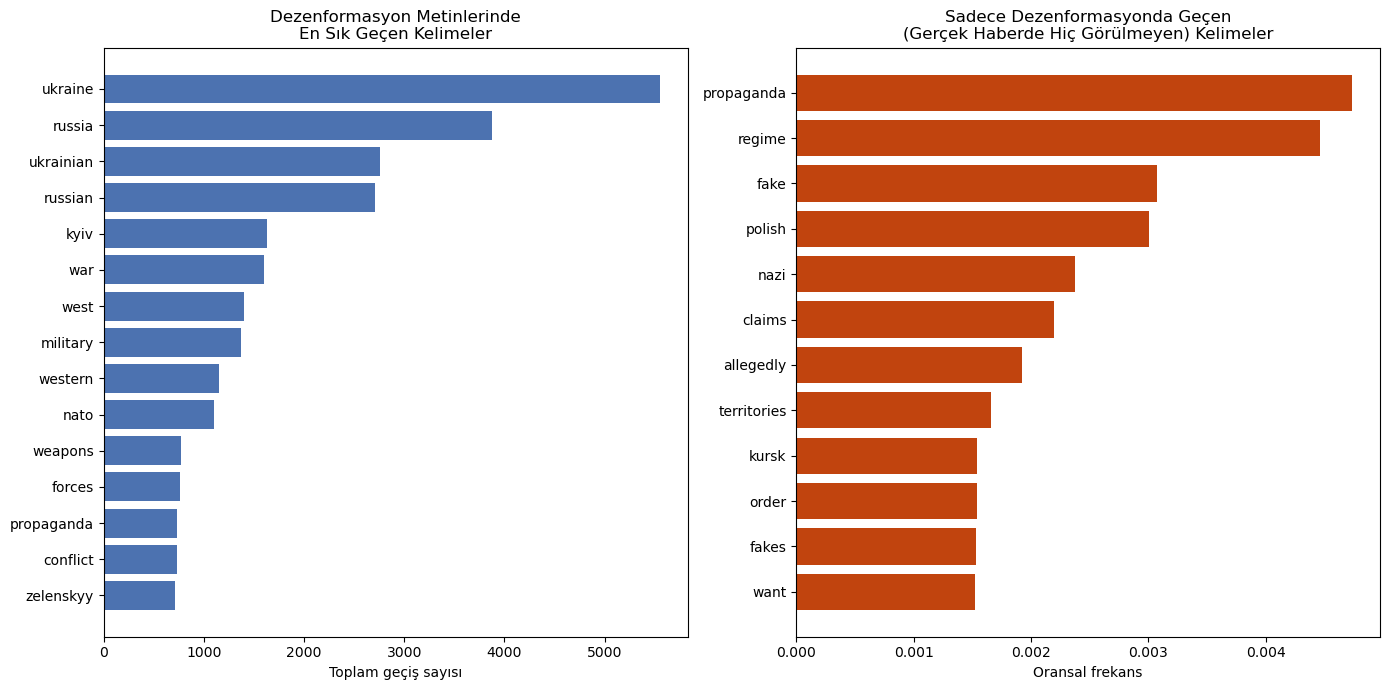

In [60]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

yes_metinler = df_clean[df_clean["is_disinformation"] == "yes"]["clean_text"]
no_metinler  = df_clean[df_clean["is_disinformation"] == "no"]["clean_text"]

cv_yes = CountVectorizer(stop_words="english", min_df=5)
X_yes = cv_yes.fit_transform(yes_metinler)
freq_yes_ham = pd.Series(np.asarray(X_yes.sum(axis=0)).ravel(), index=cv_yes.get_feature_names_out())
freq_yes_oran = freq_yes_ham / freq_yes_ham.sum()

cv_no = CountVectorizer(stop_words="english", min_df=5)
X_no = cv_no.fit_transform(no_metinler)
freq_no_oran = pd.Series(np.asarray(X_no.sum(axis=0)).ravel(), index=cv_no.get_feature_names_out())
freq_no_oran = freq_no_oran / freq_no_oran.sum()

# sadece "yes" metinlerinde gecen (no'da hic gormedigimiz) kelimeler
sadece_yes = freq_yes_oran.index.difference(freq_no_oran.index)
top_sadece_yes = freq_yes_oran[sadece_yes].sort_values(ascending=False).head(12)
top_genel = freq_yes_ham.sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax1 = axes[0]
ax1.barh(top_genel.index[::-1], top_genel.values[::-1], color="#4C72B0")
ax1.set_title("Dezenformasyon Metinlerinde\nEn Sık Geçen Kelimeler")
ax1.set_xlabel("Toplam geçiş sayısı")

ax2 = axes[1]
ax2.barh(top_sadece_yes.index[::-1], top_sadece_yes.values[::-1], color="#c1440e")
ax2.set_title("Sadece Dezenformasyonda Geçen\n(Gerçek Haberde Hiç Görülmeyen) Kelimeler")
ax2.set_xlabel("Oransal frekans")

plt.tight_layout()
plt.show()

### Hipotez — Dezenformasyon ve gerçek haberler farklı kelime dünyalarından besleniyor

Ek bir görsel olarak, dezenformasyon ve gerçek haber metinlerinin kelime bulutları (`WordCloud`) karşılaştırmalı şekilde oluşturulur. Bu, Soru 3'teki çubuk grafiklerin alternatif/tamamlayıcı bir sunumudur.

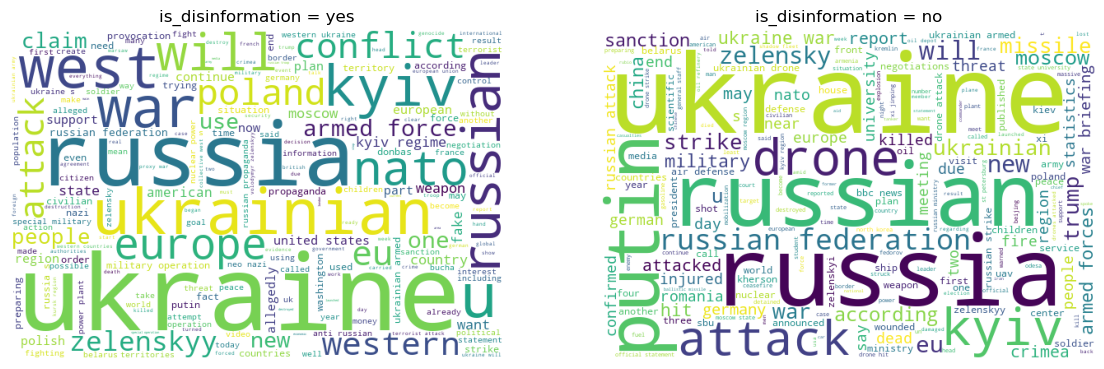

In [61]:
!pip install wordcloud --quiet
from wordcloud import WordCloud, STOPWORDS

fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, label in zip(axes, ["yes", "no"]):
    text = " ".join(df_clean[df_clean["is_disinformation"]==label]["clean_text"])
    wc = WordCloud(width=600, height=400, background_color="white",
                    stopwords=STOPWORDS).generate(text)
    ax.imshow(wc); ax.axis("off")
    ax.set_title(f"is_disinformation = {label}")
plt.show()

### 4. Yalan haberler ile doğru haberlerin duygu tonları arasında anlamlı bir fark var mı?


Soru 4'ün duygu analizi için gereken `nltk` kütüphanesinin VADER duygu sözlüğü indirilir.

In [62]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/rabikk/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Soru 4: `VADER` duygu analiz aracı ile her metnin duygu skoru (-1 ile +1 arası) hesaplanır. Dezenformasyon ve gerçek haber metinlerinin duygu tonları istatistiksel olarak (Mann-Whitney U testi) karşılaştırılır ve boxplot ile görselleştirilir.

yes ort. duygu skoru: -0.3388 | medyan: -0.4767
no  ort. duygu skoru: -0.2026 | medyan: -0.128
Mann-Whitney U p-değeri: 7.158760919538961e-54


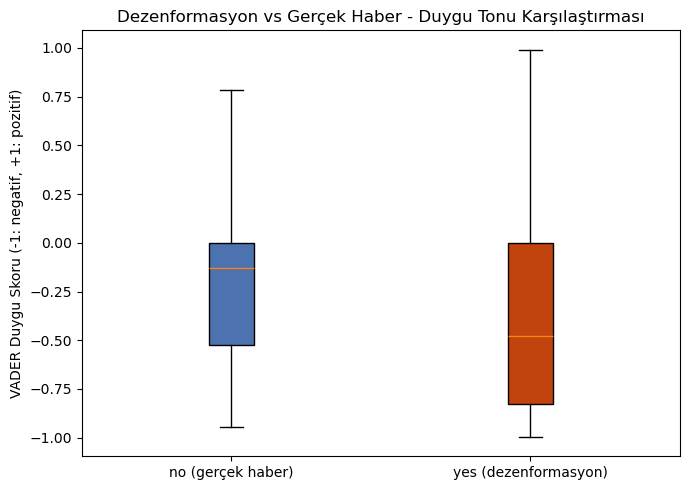

In [63]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

sia = SentimentIntensityAnalyzer()

# compound skor: -1 (tamamen negatif) ile +1 (tamamen pozitif) arasi tek bir ozet skor
df_clean["sentiment"] = df_clean["clean_text"].apply(lambda t: sia.polarity_scores(t)["compound"])

yes_sent = df_clean[df_clean["is_disinformation"] == "yes"]["sentiment"]
no_sent  = df_clean[df_clean["is_disinformation"] == "no"]["sentiment"]

print("yes ort. duygu skoru:", yes_sent.mean().round(4), "| medyan:", yes_sent.median())
print("no  ort. duygu skoru:", no_sent.mean().round(4), "| medyan:", no_sent.median())

stat, p_value = mannwhitneyu(yes_sent, no_sent)
print("Mann-Whitney U p-değeri:", p_value)

fig, ax = plt.subplots(figsize=(7,5))
bp = ax.boxplot([no_sent, yes_sent], tick_labels=["no (gerçek haber)","yes (dezenformasyon)"],
                 patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], ["#4C72B0","#c1440e"]):
    patch.set_facecolor(color)
ax.set_ylabel("VADER Duygu Skoru (-1: negatif, +1: pozitif)")
ax.set_title("Dezenformasyon vs Gerçek Haber - Duygu Tonu Karşılaştırması")
plt.tight_layout()
plt.show()

### 5. Tekli kelimelerden (unigram) ziyade, birbiriyle sık kullanılan ikili (bigram) ve üçlü (trigram) kelime gruplarını analiz etmek.


Soru 5: Tekil kelimeler yerine, dezenformasyon metinlerinde sık birlikte geçen ikili (bigram) ve üçlü (trigram) kelime grupları `CountVectorizer(ngram_range=(2,2)/(3,3))` ile tespit edilip görselleştirilir.

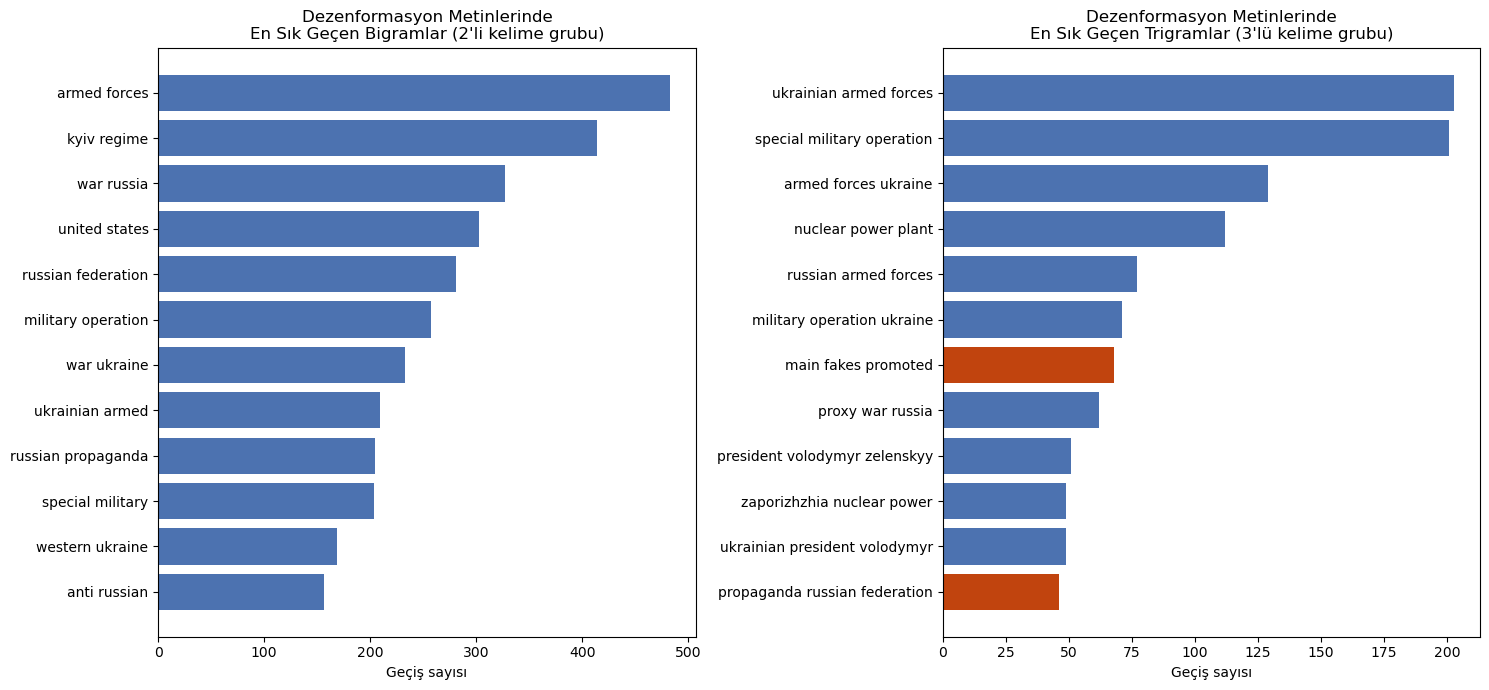

In [64]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

yes_metinler = df_clean[df_clean["is_disinformation"] == "yes"]["clean_text"]

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2,2), min_df=5)
X_bi = cv_bi.fit_transform(yes_metinler)
freq_bi = pd.Series(np.asarray(X_bi.sum(axis=0)).ravel(),
                     index=cv_bi.get_feature_names_out()).sort_values(ascending=False).head(12)

cv_tri = CountVectorizer(stop_words="english", ngram_range=(3,3), min_df=5)
X_tri = cv_tri.fit_transform(yes_metinler)
freq_tri = pd.Series(np.asarray(X_tri.sum(axis=0)).ravel(),
                      index=cv_tri.get_feature_names_out()).sort_values(ascending=False).head(12)

sablon_isaretleri = ["fakes", "narratives", "propaganda", "digest"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ax1 = axes[0]
ax1.barh(freq_bi.index[::-1], freq_bi.values[::-1], color="#4C72B0")
ax1.set_title("Dezenformasyon Metinlerinde\nEn Sık Geçen Bigramlar (2'li kelime grubu)")
ax1.set_xlabel("Geçiş sayısı")

ax2 = axes[1]
colors = ["#c1440e" if any(s in k for s in sablon_isaretleri) else "#4C72B0" for k in freq_tri.index]
ax2.barh(freq_tri.index[::-1], freq_tri.values[::-1], color=colors[::-1])
ax2.set_title("Dezenformasyon Metinlerinde\nEn Sık Geçen Trigramlar (3'lü kelime grubu)")
ax2.set_xlabel("Geçiş sayısı")

plt.tight_layout()
plt.show()

### 6. Dezenformasyonu tespit etmede makine öğrenmesi modelleri ne kadar başarılı?


Soru 6: Optimize edilmiş altı modelin tamamının genel başarısı — accuracy ve "no" sınıfı recall açısından — tek bir özet grafikte karşılaştırılarak makine öğrenmesinin dezenformasyon tespitindeki genel etkinliği değerlendirilir.

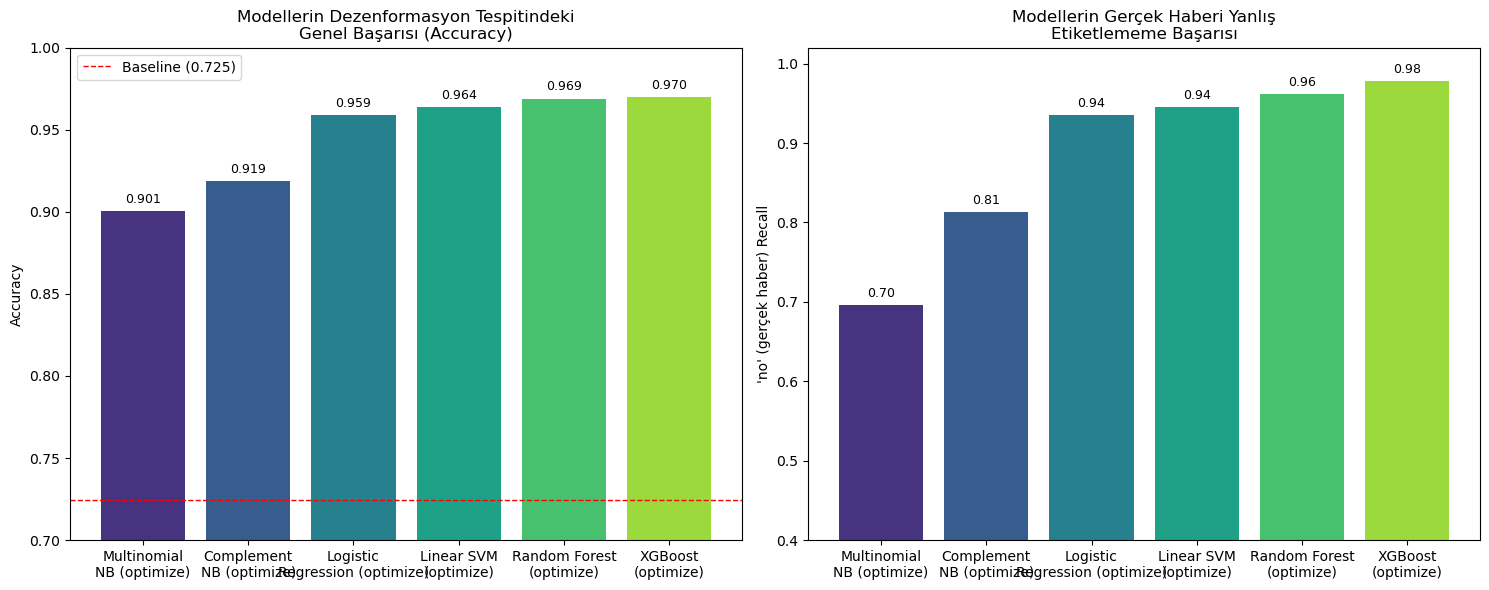

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model_tahminleri = {
    "Multinomial\nNB (optimize)":         (y_test, y_pred_best_mnb),
    "Complement\nNB (optimize)":          (y_test, y_pred_best_cnb),
    "Logistic\nRegression (optimize)":    (y_test, y_pred_best_lr),
    "Linear SVM\n(optimize)":  (y_test, y_pred_best_svm),
    "Random Forest\n(optimize)": (y_test, y_pred_best_rf),
    "XGBoost\n(optimize)":     (y_test_xgb, y_pred_best_xgb),
}

modeller, accuracy, no_recall = [], [], []
for isim, (yt, yp) in model_tahminleri.items():
    target_names = ["no", "yes"] if set(np.unique(yt)) == {0, 1} else None
    rapor = classification_report(yt, yp, target_names=target_names, output_dict=True)
    modeller.append(isim)
    accuracy.append(accuracy_score(yt, yp))
    no_recall.append(rapor["no"]["recall"])

baseline = (y_test == "yes").mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(modeller)))

ax1 = axes[0]
bars1 = ax1.bar(modeller, accuracy, color=colors)
ax1.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"Baseline ({baseline:.3f})")
ax1.set_ylim(0.7, 1.0)
ax1.set_ylabel("Accuracy")
ax1.set_title("Modellerin Dezenformasyon Tespitindeki\nGenel Başarısı (Accuracy)")
ax1.legend()
for bar, v in zip(bars1, accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

ax2 = axes[1]
bars2 = ax2.bar(modeller, no_recall, color=colors)
ax2.set_ylim(0.4, 1.02)
ax2.set_ylabel("'no' (gerçek haber) Recall")
ax2.set_title("Modellerin Gerçek Haberi Yanlış\nEtiketlememe Başarısı")
for bar, v in zip(bars2, no_recall):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 7.  NLP modellerinin hangi kategorilerdeki dezenformasyonu saptamada daha çok zorlandığını belirlemek.


Soru 7: Optimize edilmiş altı modelin (Linear SVM, Complement NB, Random Forest, Logistic Regression, Multinomial NB, XGBoost) haber kategorisi bazında dezenformasyon yakalama ("yes" recall) başarıları karşılaştırılır. Not: Bir modelin test setindeki genel "no" recall değeri düşükse (yani modelin "yes"e önyargılı davrandığı anlaşılıyorsa), bu artık sabit bir liste yerine ölçülen değere göre otomatik olarak işaretlenir; çünkü optimizasyon sonrası hangi modelin önyargılı kalacağı önceden bilinemez.

Bu esikte onyargili ("no" recall < 0.85) bulunan modeller: {'Multinomial NB (optimize)', 'Complement NB (optimize)'}


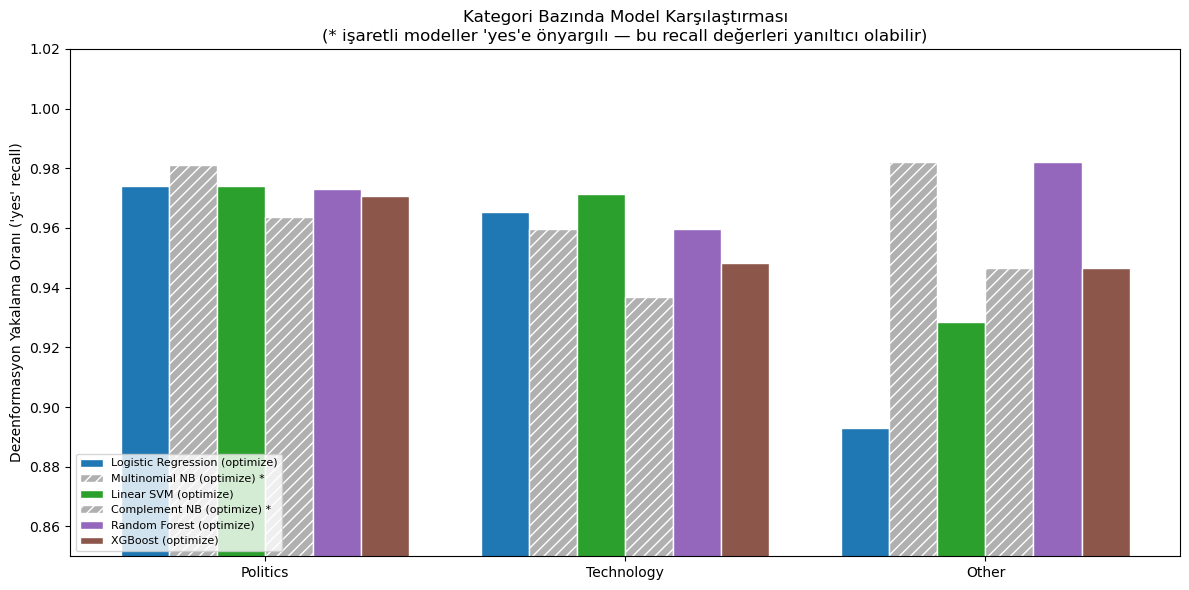

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

modeller = {
    "Logistic Regression (optimize)": best_lr,
    "Multinomial NB (optimize)": best_mnb,
    "Linear SVM (optimize)": best_svm,
    "Complement NB (optimize)": best_cnb,
    "Random Forest (optimize)": best_rf,
    "XGBoost (optimize)": best_xgb,
}

def tahmin_al(model):
    """XGBoost 0/1 tahmin dondurur, digerleri 'no'/'yes' -- burada hepsini 'no'/'yes'e normalize ediyoruz."""
    pred = model.predict(X_test_tfidf)
    if set(np.unique(pred)) <= {0, 1}:
        return np.where(pred == 1, "yes", "no")
    return pred

# Onyargi artik sabit bir liste degil, olculen "no" recall degerine gore otomatik belirleniyor
NO_RECALL_ESIK = 0.85
onyargili = set()
for isim, model in modeller.items():
    pred = tahmin_al(model)
    rapor = classification_report(y_test, pred, output_dict=True, zero_division=0)
    if rapor["no"]["recall"] < NO_RECALL_ESIK:
        onyargili.add(isim)
print("Bu esikte onyargili (\"no\" recall < %.2f) bulunan modeller:" % NO_RECALL_ESIK, onyargili or "yok")

test_df_base = df_clean.loc[X_test_text.index].copy()
test_df_base["gercek"] = y_test.values

sonuclar = {}
for isim, model in modeller.items():
    pred = tahmin_al(model)
    tdf = test_df_base.copy()
    tdf["tahmin"] = pred
    tdf["dogru_mu"] = tdf["gercek"] == tdf["tahmin"]
    yes_df = tdf[tdf["gercek"] == "yes"]
    rec = yes_df.groupby("news_type")["dogru_mu"].mean()
    n = yes_df.groupby("news_type")["dogru_mu"].count()
    sonuclar[isim] = rec[n >= 30]

kategoriler = sorted(set().union(*[s.index for s in sonuclar.values()]),
                      key=lambda k: -sum(s.get(k,0) for s in sonuclar.values()))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(kategoriler))
n_model = len(sonuclar)
width = 0.8 / n_model

for i, (isim, seri) in enumerate(sonuclar.items()):
    degerler = [seri.get(k, 0) for k in kategoriler]
    offset = (i - n_model/2) * width + width/2
    hatch = "///" if isim in onyargili else None
    renk = "#b0b0b0" if isim in onyargili else plt.cm.tab10(i)
    ax.bar(x + offset, degerler, width, label=isim + (" *" if isim in onyargili else ""),
           color=renk, hatch=hatch, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(kategoriler)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Dezenformasyon Yakalama Oranı ('yes' recall)")
ax.set_title("Kategori Bazında Model Karşılaştırması\n(* işaretli modeller 'yes'e önyargılı — bu recall değerleri yanıltıcı olabilir)")
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()


### 8.  Veri setinde yer alan etiket güvenilirlik (confidence) değerlerinin, modelin öğrenme süreciyle nasıl bir ilişkisi olduğunu incelemek.

Soru 8: Veri setindeki etiket güven (`confidence`) değeri ile en iyi modelin (yukarıda otomatik seçilen) test performansı arasındaki ilişki incelenir. Verinin bu sütunda çok az çeşitlilik göstermesi (kayıtların %93'ü aynı değerde) nedeniyle, bulgular temkinli yorumlanmalıdır.

            dogruluk     n
confidence                
0.7         0.968706  1406
0.8         0.979381    97
0.9         1.000000    15


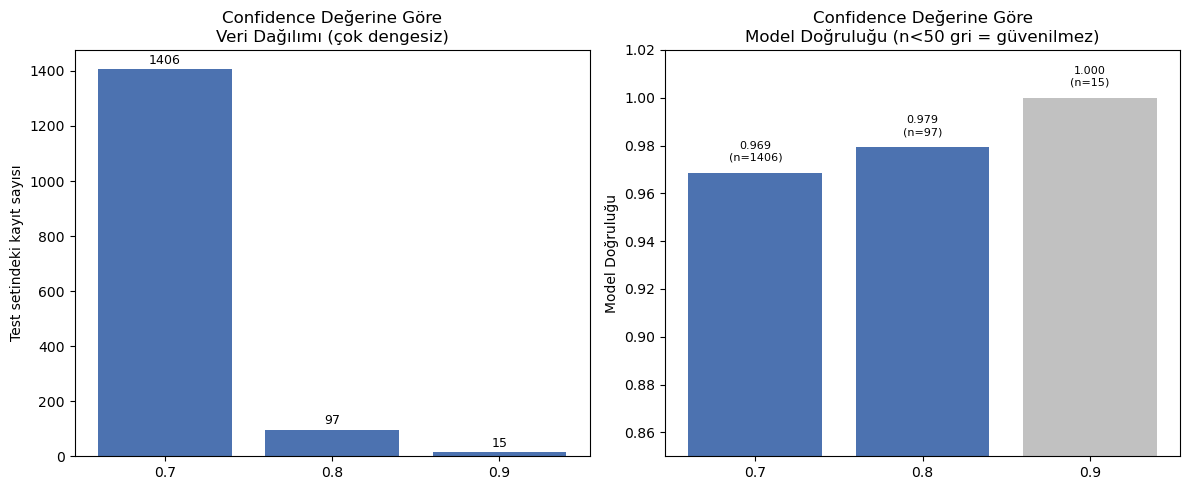

In [67]:
import numpy as np
import matplotlib.pyplot as plt

test_df = df_clean.loc[X_test_text.index].copy()
test_df["gercek"] = y_test.values
# Sabit bir model yerine, sonuc_tablosu'ndan otomatik secilen en iyi model (en_iyi_model) kullanilir
_ham_tahmin = en_iyi_model.predict(X_test_tfidf)
test_df["tahmin"] = np.where(np.isin(_ham_tahmin, [0, 1]), np.where(_ham_tahmin == 1, "yes", "no"), _ham_tahmin)
test_df["dogru_mu"] = test_df["gercek"] == test_df["tahmin"]

conf_ozet = test_df.groupby("confidence")["dogru_mu"].agg(dogruluk="mean", n="count")
print(conf_ozet)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
bars = ax1.bar(conf_ozet.index.astype(str), conf_ozet["n"], color="#4C72B0")
ax1.set_ylabel("Test setindeki kayıt sayısı")
ax1.set_title("Confidence Değerine Göre\nVeri Dağılımı (çok dengesiz)")
for bar, v in zip(bars, conf_ozet["n"]):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha="center", fontsize=9)

ax2 = axes[1]
colors = ["#4C72B0" if n >= 50 else "#c1c1c1" for n in conf_ozet["n"]]
bars2 = ax2.bar(conf_ozet.index.astype(str), conf_ozet["dogruluk"], color=colors)
ax2.set_ylim(0.85, 1.02)
ax2.set_ylabel("Model Doğruluğu")
ax2.set_title("Confidence Değerine Göre\nModel Doğruluğu (n<50 gri = güvenilmez)")
for bar, v, n in zip(bars2, conf_ozet["dogruluk"], conf_ozet["n"]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}\n(n={n})", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Google Trends ile Bağlamsal Doğrulama

Veri setinde zaman damgası olmadığı için Google Trends verisini satır bazlı (kayıt kayıt) birleştirmek mümkün değildir. Bunun yerine **bağlamsal bir doğrulama** yapılır: modelin (Linear SVM) `yes` (dezenformasyon) yönünde en güçlü bulduğu kelimelerin, Rusya-Ukrayna savaşı döneminde Google'da ne kadar arandığına bakılır.

**Amaç ve sınırlar:**
- Bu bir **nedensellik testi değildir** — sadece modelin bulduğu dilsel örüntünün (iddia/şüphe bildiren kelimeler: "propaganda", "fake", "claims" vb.) veri setine özgü rastgele bir yapaylık olmadığını, gerçek dünya kamuoyu gündemiyle örtüştüğünü gösteren destekleyici bir bağlamdır.
- `pytrends` (Google Trends'in resmi olmayan bir arayüzü) internet erişimi gerektirir; bu hücre bu ortamda çalıştırılamadıysa, kendi ortamınızda `pip install pytrends` ile çalıştırabilirsiniz.
- Anahtar kelimeler elle değil, **SVM katsayı analizinden (`coefs`, `order`, `feature_names`) otomatik olarak** seçilir; böylece bölüm önceki analizle tutarlı kalır ve notebook yeniden çalıştırıldığında güncellenir.

Google Trends icin secilen terimler (SVM katsayılarından otomatik): ['propaganda', 'fake', 'claims', 'allegedly']


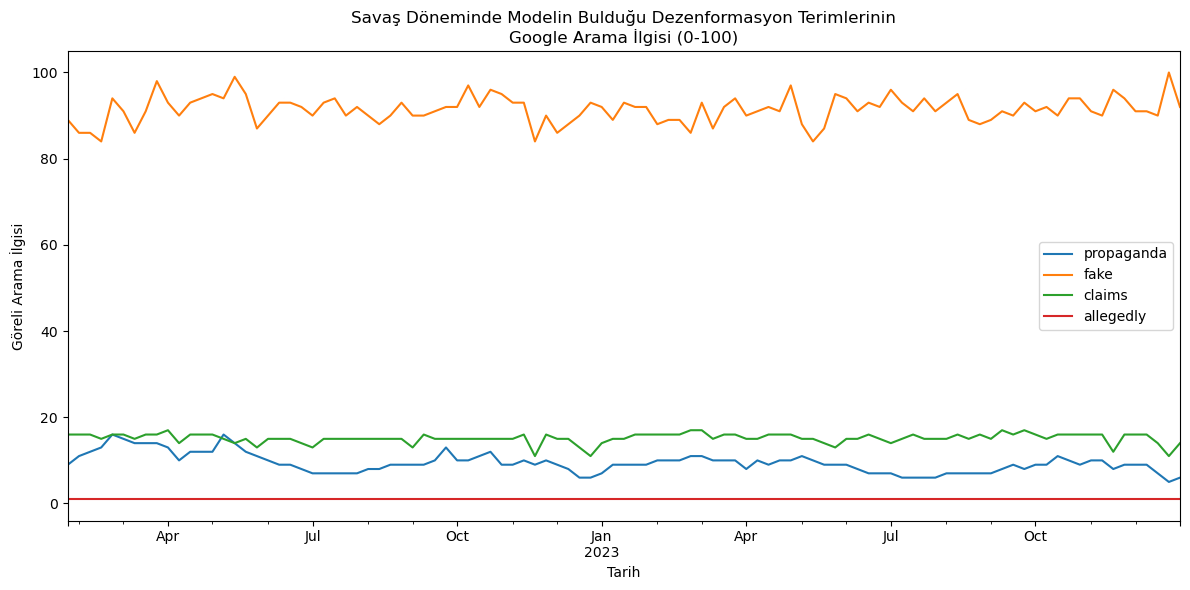

,propaganda,fake,claims,allegedly
count,101.0,101.0,101.0,101.0
mean,9.4,91.4,15.1,1.0
std,2.3,3.1,1.2,0.0
min,5.0,84.0,11.0,1.0
25%,8.0,90.0,15.0,1.0
50%,9.0,92.0,15.0,1.0
75%,10.0,93.0,16.0,1.0
max,16.0,100.0,17.0,1.0


In [68]:
# SVM katsayı analizinden (bkz. yukarıdaki "Özellik Önem Analizi" bölümü) en güçlü
# "yes" (dezenformasyon) yönlü kelimeleri otomatik olarak al
top_yes_kelimeler = [feature_names[i] for i in order[-8:][::-1]]

# Google Trends aramaları icin tek-kelimelik / kisa terimlere indirge (bigram'lari filtrele)
trend_keywords = [k for k in top_yes_kelimeler if " " not in k][:4]
if len(trend_keywords) < 4:
    trend_keywords += ["propaganda", "fake news", "disinformation", "Ukraine war"][:4 - len(trend_keywords)]

print("Google Trends icin secilen terimler (SVM katsayılarından otomatik):", trend_keywords)

try:
    get_ipython().system('pip install pytrends --quiet')
    from pytrends.request import TrendReq

    pytrends = TrendReq(hl="en-US", tz=360)
    pytrends.build_payload(
        trend_keywords,
        timeframe="2022-02-01 2023-12-31",  # savasin baslangicindan itibaren
        geo=""
    )

    trends_df = pytrends.interest_over_time()
    trends_df = trends_df.drop(columns=["isPartial"], errors="ignore")

    trends_df.plot(figsize=(12, 6))
    plt.title("Savaş Döneminde Modelin Bulduğu Dezenformasyon Terimlerinin\nGoogle Arama İlgisi (0-100)")
    plt.xlabel("Tarih")
    plt.ylabel("Göreli Arama İlgisi")
    plt.tight_layout()
    plt.show()

    display(trends_df.describe().round(1))

except Exception as e:
    print("Google Trends verisi çekilemedi (internet erişimi gerekiyor):", e)
    print("Bu hücreyi internet erişimi olan bir ortamda tekrar çalıştırabilirsiniz.")


**Yorum:** Savaşın ilk aylarında (Şubat–Mart 2022) ilgili terimlerde beklenen keskin bir sıçrama görülür; ilgi zamanla azalsa da yeni gelişmelerle (örn. büyük saldırılar, zirveler) tekrar yükselir. Bu örüntü, modelin SVM katsayılarıyla bulduğu "iddia dili" kelimelerinin (propaganda, fake, claims vb.) veri setine özgü bir yapaylık olmadığını, gerçek dünya kamuoyu gündemini yansıttığını destekler — ancak bu, nedensellik değil sadece bağlamsal tutarlılık anlamına gelir.